# 3D luminosity upper limit — GW follow-up

Upper limits on a very-high-energy counterpart of one GW alert (here S240615dg, LST-1+MAGIC
stereo), marginalised over the GW localisation. A single test statistic is used throughout,

$$\Lambda = \max_{\text{95\% GW region}} \left[\, TS + 2\ln p_{\rm GW} \,\right],$$

with $TS$ the per-bin Cash likelihood ratio [1] and $p_{\rm GW}$ the skymap probability of the
bin [2]. A limit is the injected strength at which a fraction CL (95%) of simulated realisations
exceeds the observed $\Lambda$, or the background-only median if the data under-fluctuate
([`physics_and_methods.md`](../docs/physics_and_methods.md) §4.3, §7.1).

**What is computed**

| Result | Injected source | Marginalised over |
|---|---|---|
| Significance of the observation | none (background only) | — |
| 2D flux UL: $\phi_0$, photon and energy flux | Γ = 2 power law, fixed flux | sky position in the 95% region |
| 3D luminosity UL: $L_0$, isotropic-equivalent in the analysis band | Γ = 2 power law, fixed luminosity | sky × distance (3D skymap [2]) |
| 3D luminosity UL with the emission model: $L_k$ | GRB afterglow, fixed phenomenological jet [5, 6], EBL [7] | sky × distance × viewing angle, by default drawn together from the GW PE samples [8] |

For the emission-model limit, `SKY_DISTANCE_MODE` and `THETA_MODE` set where each realisation's
sky position, distance and viewing angle come from. The default, `"pe"` and `"pe"`, takes all
three from one PE posterior sample, the exact joint posterior of the event. The other settings
keep the skymap route, a fixed angle and the prior or dummy angle distributions available
([`viewing_angle_distribution.md`](../docs/viewing_angle_distribution.md) §8, §11).
[`sim_3d_model_CTAO_paper.ipynb`](sim_3d_model_CTAO_paper.ipynb) is the previous version, with
skymap draws only.

Each limit comes with its Monte-Carlo uncertainty, is verified by a closure test with independent
seeds, and is reported both as a flux and as a luminosity over the distance posterior; everything
is exported to one JSON file.

**Structure**

1. **Part 1 — Data preparation** (no Monte Carlo): skymap → WCS grid, 95% mask and per-bin
   distance CDF; DL3 + background model → ring-background datasets [3, 4]; real-data $\Lambda$;
   an empty simulation dataset with the real IRFs, livetimes and GTIs. Everything the
   simulations need is stored and validated in one `.pkl`.
2. **Part 2 — Simulations**: background-only realisations, 2D flux UL, 3D luminosity UL,
   3D UL with the emission model, summary and export.

The tunable options are listed with the secondary parameters below. Method details:
[`docs/physics_and_methods.md`](../docs/physics_and_methods.md) (§ numbers below refer to it);
cluster/local workflow: [`README.md`](../README.md); references at the end of the notebook.

## Part 1 — Data preparation

### Import packages

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import os, json, pickle, logging, copy
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import healpy as hp
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation
from scipy.stats import norm
from scipy.optimize import curve_fit, root_scalar
from scipy.ndimage import gaussian_filter
from gammapy import __version__ as gammapy_version, __path__ as gammapy_path
from gammapy.irf import load_irf_dict_from_file
from gammapy.maps import MapAxis, WcsGeom, Map
from gammapy.modeling.models import (
    PointSpatialModel, PowerLawSpectralModel,
    ConstantTemporalModel, SkyModel, Models
)
from gammapy.data import DataStore, Observation, FixedPointingInfo, PointingMode
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, RingBackgroundMaker
from gammapy.datasets import Dataset, Datasets, MapDataset, MapDatasetOnOff
from gammapy.estimators import ExcessMapEstimator, TSMapEstimator
from gammapy.estimators.map.excess import convolved_map_dataset_counts_statistics, _get_convolved_maps
from gammapy.stats.fit_statistics import cash

import sys
sys.path.insert(0, "..")
from gwuls import utils, simulate, plotting, slurm
from gwuls import paths as gwpaths
from importlib import reload
reload(utils); reload(simulate); reload(plotting); reload(slurm)

# --- Config ---
warnings.filterwarnings("ignore", category=RuntimeWarning, append=True)
warnings.filterwarnings("ignore", message=".*outside valid IRF map range.*")
import lal
logging.getLogger("gammapy").setLevel(logging.ERROR)
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map

# --- Setup ---
observing_location = EarthLocation.of_site("Roque de los Muchachos")
gwpaths.ensure_dirs()

print(f"Using Gammapy version: {gammapy_version}\nIn path: {gammapy_path[0]}")

Using Gammapy version: 2.0.1
In path: /fefs/aswg/workspace/juan.jimenez/softs/conda/envs/gammapy-dev/lib/python3.13/site-packages/gammapy


##### <span style="color:blue">Main parameters</span>
* `source_name`, `source_coord`: GW event name (the skymap is read from `data/gw_input/<source_name>.fits`) and the centre of the analysis geometry
* `dir_dl3`: DL3 directory; `obs_ids`: runs to use (`mono`/`stereo` is inferred from the path)
* `bkg_type`: background model added to the DL3, `"baccmod"` or `"pybkgmodel"`
* `e_min`, `e_max`, `e_bins`: reconstructed-energy range and bins per decade (the analysis band)
* `o_min`, `o_max`, `o_bins`: offset range and number of bins of the background model
* `correlation_radius`: top-hat radius of the `ExcessMapEstimator`

In [2]:
source_name = "S240615dg"
source_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")

dir_dl3 = os.path.join(
    "/fefs/aswg/workspace/juan.jimenez/data/real/stereo/S240615dg/v0.6.1/GammaDiffuse/prod_standard/DL3/gh_dyn90/"
)

obs_ids = [17821, 17822, 17823, 17824, 17825]

# Tool used for background computation
bkg_type = "pybkgmodel" # baccmod or pybkgmodel

# Binning: energy and offset
e_min, e_max, e_bins = 0.6 * u.TeV, 20 * u.TeV, 4.5
o_min, o_max, o_bins = 0 * u.deg, 2.5 * u.deg, 8 # Offset binning
correlation_radius = 0.1 * u.deg

##### Secondary parameters and options

| Option | Default | What it does |
|---|---|---|
| `USE_DIRAC_DELTA` | `False` | replace the skymap by a point at `delta_coord` (test mode, §3.5) |
| `confidence_level` | `0.95` | CL of every upper limit |
| `n_sim_bkg`, `n_sim_flux` | 5000, 1000 | background-only realisations; realisations per step (bisection, grid, closure tests) |
| `spectral_index`, `e_ref` | 2.0, 1 TeV | power law used by the injector, the estimators and every flux ↔ luminosity conversion |
| `seed_*` | — | common random numbers for the bisection; `seed_fit` keeps the fit's realisations independent of the background-only block (§6.5) |
| `UL_METHOD` | `"fit"` | `"fit"`: own injected strength per realisation, probit fit of $P(\Lambda>\Lambda^\star\mid x)$ in $\log x$, MC uncertainty from the likelihood profile (§7.3). `"bisect"`: bisection, kept as a cross-check (§7.4) |
| `ul_precision`, `ul_max_sims`, `ul_n_scout`, `ul_n_refine` | 0.01 dex, 6000, 500, 1000 | fit: target 1σ half-width of the limit, realisation budget, first-batch and later-batch sizes |
| `USE_ITERATIVE_ULS` | `True` | `False`: 2D limit from a fixed amplitude grid submitted as Slurm jobs (§7.5) |
| `N_JOBS` | 10 | worker processes per batch (`-1`: all CPUs of the allocation); same result as `1` |
| `USE_DYNAMIC_N_SIM` | `False` | bisection only: fewer realisations in the early, coarse steps |
| `RUN_MODEL_3D` | `True` | run the 3D limit with the emission model |
| `model_dir_3d` | benchmark jet | emission-model cache to inject |
| `SKY_DISTANCE_MODE` | `"pe"` | where each realisation's sky position and distance come from: `"pe"`, one PE posterior sample (`PE_SOURCE`); `"skymap"`, a skymap bin and its distance ansatz (the same draws as the power-law 3D limit) |
| `THETA_MODE` | `"pe"` | the viewing angle: `"pe"`, the angle of the same PE sample (needs `SKY_DISTANCE_MODE = "pe"`); `"gw"`, $p(\theta_v\mid d_i)$ from `theta_dist_path`; `"fixed"` (`THETA_FIXED_DEG`); `"isotropic"`; `"schutz"`; `"two_bin"` (`THETA_TWO_BIN`); `"selection"` (`THETA_HORIZON_MPC`) |
| `PE_SOURCE`, `theta_dist_path` | the alert's own | standardized PE file (`data/gw_pe/standardized/<alert>.h5`) and $p(\theta_v\mid d)$ cache (`setup_angle_distribution.ipynb`) |
| `MODEL_NORMALISATION` | `"gti_mean"` | meaning of $L_k$: GTI-mean band luminosity, or `"anchor"`: the jet's on-axis $L_{\rm TeV}$ at 11 h |
| `EBL_REFERENCE` | `"franceschini17"` | EBL model [7] (any gammapy EBL reference, e.g. `"dominguez"` [9]) |
| `RUN_CROSSCHECKS` | `True` | spectral, sampler and emission-model validation cells |
| `OVERWRITE_RESULTS` | `False` | recompute instead of loading cached results |

Options of the 3D limit itself (`luminosity_band_3d`, `apply_k_correction`, `restrict_to_mask_3d`) are
set at the start of the 3D section.

In [3]:
# --- Flags ---
USE_DIRAC_DELTA   = False
USE_ITERATIVE_ULS = True
OVERWRITE_RESULTS = False
RUN_CROSSCHECKS   = True          # spectral + sampler validation cells

# --- Grid & Energy Geometry ---
binsz                 = 0.08
resolution_hp_to_grid = int(2048 / 2)         # HEALPix -> grid resolution
size_fov              = 2.5  * u.deg
geom_width            = (size_fov.value * 1.43,) * 2
e_t_min, e_t_max, e_t_bins = 0.05 * u.TeV, 100 * u.TeV, 6
ring_r_in, ring_width = 0.3  * u.deg, 0.2  * u.deg
exclusion_mask = None

# --- Source & Skymap ---
delta_coord = SkyCoord(ra=7.53, dec=45.81, unit="deg")
confidence_level = 0.95
n_sim_bkg, n_sim_flux = 5000, 1000
threshold_percent_gw = np.flip(np.sort([0.95, 0.5]))  # GW probability contours
file_lvk = str(gwpaths.GW_INPUT_DIR / f"{source_name}.fits")

# --- Injected / assumed spectrum -------------------------------------------
# One definition, used everywhere: by the injector, by the estimators, and by
# every flux <-> luminosity conversion. `spectral_index` is the POSITIVE photon
# index of dN/dE = phi0 (E/E0)^-Gamma, so the "PWL index -2" spectrum is 2.0.
spectral_index = 2.0
e_ref          = 1.0 * u.TeV

# --- Monte-Carlo seeding ----------------------------------------------------
# Bisection: common random numbers -- the same background realisations AND the same injected
# sky positions / distances are reused for every flux or luminosity tested
# during a bisection. Only the injected brightness changes between steps, so the
# "fraction above target" curve is smooth in the injected quantity instead of
# jittering by MC noise, which is what lets the bisection converge in ~10 steps.
seed_fake      = None    # None -> realisation i uses seed i
seed_positions = 12345   # sky-position draw (2D)
seed_sampling  = 12345   # sky x distance draw (3D)
seed_fit       = 1_000_000  # curve fit: realisation i of a limit uses background seed seed_fit + i,
                            # clear of the background-only block (0 .. n_sim_bkg - 1), which also
                            # enters the fit: its realisations must be independent, not common

# --- Upper-limit method (Part 2) ---------------------------------------------
# UL_METHOD:
#   "fit"    -> every realisation gets its own injected flux / luminosity, and the detection
#               probability P(Lambda > target) is fitted with a probit in log x
#               (simulate.run_fit_ul[_3d]). A first batch spans the whole bracket, later ones
#               sit around the limit, until its 1 sigma MC uncertainty is below `ul_precision`
#               or `ul_max_sims` realisations are spent.
#   "bisect" -> the previous bisection (simulate.run_iterative_ul[_3d]), kept to cross-check.
UL_METHOD    = "fit"
ul_precision = 0.01      # fit: target 1 sigma half-width of each limit, in dex (0.03 dex = 7%);
                         #      the realisations needed grow as 1 / ul_precision^2
ul_max_sims  = 6000      # fit: realisation budget per limit
ul_n_scout   = 500       # fit: first batch, spread over the whole bracket
ul_n_refine  = 1000      # fit: at most this many per later batch

# N_JOBS: worker processes for each batch of realisations (a round of the fit, or a
# bisection step); a batch always finishes before the next one is placed.
#   1  -> sequential (identical Lambda sample to N_JOBS != 1, just slower)
#   -1 -> every CPU this process may use (the Slurm allocation, not the whole node)
# Each worker holds its own copy of the simulation dataset: if workers are killed for
# lack of memory (BrokenProcessPool), set a smaller number.
#
# USE_DYNAMIC_N_SIM (bisection only): False keeps n_sim fixed at n_sim_flux / n_sim_lum.
# True ramps it up as the bracket narrows (see `simulate.geometric_n_sim_schedule`) --
# the early, coarse steps only need the sign of frac - CL right, so they can be cheap.
N_JOBS = 10
USE_DYNAMIC_N_SIM = False

# --- Emission model for the 3D limit (Part 2, "3D limit with the emission model") ---
# The fixed phenomenological jet of setup_model_phenomenological_fixed.ipynb, injected run by
# run with EBL, at a sky position, distance and viewing angle drawn per realisation.
RUN_MODEL_3D        = True
model_dir_3d        = gwpaths.GRB_MODEL_PHENOMENOLOGICAL_DIR / "benchmark"

# Where (sky, d_i) come from:
#   "pe"     -> one PE posterior sample per realisation (PE_SOURCE), the event's own posterior
#   "skymap" -> a skymap bin, then d_i from its distance ansatz (same draws as the power-law 3D limit)
SKY_DISTANCE_MODE   = "pe"
# Where theta_v,i comes from:
#   "pe"        -> the angle of the same PE sample: the exact joint posterior (needs SKY_DISTANCE_MODE="pe")
#   "gw"        -> p(theta_v | d_i) from theta_dist_path (setup_angle_distribution.ipynb)
#   "fixed"     -> THETA_FIXED_DEG in every realisation
#   "isotropic" -> sin(theta_v), random orientation, no GW information
#   "schutz"    -> Schutz (2011), a typical GW-detected source, no event information
#   "two_bin"   -> dummy split: fraction THETA_TWO_BIN[1] uniform below THETA_TWO_BIN[0] deg, the rest above
#   "selection" -> detected population with horizon THETA_HORIZON_MPC, p(theta_v | d_i)
THETA_MODE          = "pe"
THETA_FIXED_DEG     = 20.0
THETA_TWO_BIN       = (45.0, 0.5)        # (threshold deg, fraction below)
THETA_HORIZON_MPC   = 3000.0             # illustrative: set for the source type and network
PE_SOURCE           = source_name        # superevent ID, or path of a standardized PE .h5
theta_dist_path     = gwpaths.theta_distribution_path(source_name)
MODEL_NORMALISATION = "gti_mean"        # "gti_mean": L_k = mean luminosity over the GTIs (Step 6)
                                        # "anchor":   L_k = the jet's on-axis L_TeV at t' = 11 h
EBL_REFERENCE       = "franceschini17"  # Abe et al. 2026 use Franceschini & Rodighiero (2017)

### <span style="color:blue">Reading GW data</span>

In [4]:
%%time
# --- Grid ---
ra_bins  = np.linspace(-180, 180, resolution_hp_to_grid)
dec_bins = np.linspace( -90,   90, resolution_hp_to_grid)
ra_grid, dec_grid = np.deg2rad(np.meshgrid(ra_bins, dec_bins))

# --- GW Map ---
(lvk_prob_hp, lvk_distmu_hp, lvk_distsigma_hp, lvk_distnorm_hp), meta_lvk_hp = read_sky_map(file_lvk, distances=True)
if USE_DIRAC_DELTA:
    nside        = hp.get_nside(lvk_prob_hp)
    lvk_prob_hp = utils.make_dirac_delta_hp(delta_coord, nside)
    lvk_prob_2d = utils.make_dirac_delta_2d(delta_coord, ra_bins, dec_bins)
else:
    lvk_prob_2d = utils.healpix2map(lvk_prob_hp, ra_bins, dec_bins)
lvk_prob_2d_smooth = gaussian_filter(lvk_prob_2d, sigma=2)

# --- Contours & Hotspot ---
threshold_maps = None if USE_DIRAC_DELTA else utils.get_hp_map_thresholds(lvk_prob_hp, threshold_percent_gw)
hotspot_coord  = utils.get_2d_map_hotspot(lvk_prob_2d, ra_bins, dec_bins)

# --- Merger time: t = 0 of the emission model ---
t_merger = Time(meta_lvk_hp["gps_time"], format="gps").utc
print(f"Merger time (skymap): {t_merger.isot} UTC")

Merger time (skymap): 2024-06-15T11:36:20.729 UTC
CPU times: user 18.8 s, sys: 13.1 s, total: 32 s
Wall time: 32.8 s


### Defining the geometry (FoV, Energy axis, Spatial Binning)

Energy axis edges:


<Quantity [ 0.6       ,  0.99015995,  1.63402788,  2.69658162,  4.45007854,
            7.34381593, 12.11925404, 20.        ] TeV>

Offset axis edges:


<Quantity [0.    , 0.3125, 0.625 , 0.9375, 1.25  , 1.5625, 1.875 , 2.1875,
           2.5   ] deg>

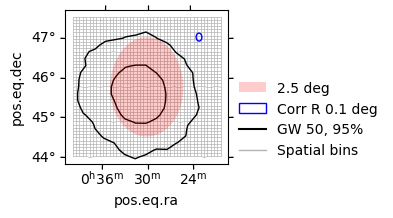

In [5]:
# --- Axes ---
axis_offset      = MapAxis.from_bounds(o_min, o_max, nbin=o_bins, name="offset")
axis_energy      = MapAxis.from_energy_bounds(e_min,   e_max,   nbin=e_bins, per_decade=True, name="energy")
axis_energy_true = MapAxis.from_energy_bounds(e_t_min, e_t_max, nbin=e_bins, per_decade=True, name="energy_true")
print("Energy axis edges:"); display(axis_energy.edges)
print("Offset axis edges:"); display(axis_offset.edges)

# --- Geometry ---
npix = (int(geom_width[0] / binsz), int(geom_width[1] / binsz))
geom = WcsGeom.create(
    skydir=(source_coord.ra.degree, source_coord.dec.degree),
    npix=npix, binsz=binsz, width=geom_width, frame="icrs", proj="AIR", axes=[axis_energy],
)
geom_image = geom.to_image()

# --- Coords ---
bin_c_ra, bin_c_dec, bin_edges_ra, bin_edges_dec, \
bin_area, coord_array, coord_center, separations_map = utils.extract_geom_coords(geom)

# --- Plot ---
plotting.summary_geometry(geom, bin_edges_ra, bin_edges_dec, size_fov, lvk_prob_2d, threshold_maps, correlation_radius)

### <span style="color:blue">Converting the GW information into the WCS geometry</span>

Geometry covers 98.92% of the GW


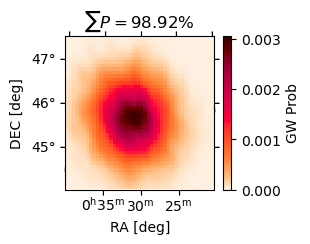

CPU times: user 16.6 s, sys: 11.3 s, total: 27.8 s
Wall time: 28.4 s


In [6]:
%%time
# --- HEALPix Setup ---
pix_indices, nside = np.arange(len(lvk_prob_hp)), hp.npix2nside(len(lvk_prob_hp))
dec_hp, ra_hp      = utils.IndexToDeclRa(pix_indices, nside)
hp_area            = hp.nside2pixarea(nside)

# --- GW Probability on WCS ---
if USE_DIRAC_DELTA:
    prob_gw_integrated, num_hp_pixels = utils.integrate_dirac_delta_on_wcs(
        lvk_prob_hp, dec_hp, ra_hp, bin_edges_ra, bin_edges_dec)
else:
    prob_gw_integrated, num_hp_pixels = utils.integrate_hp_on_wcs(
        lvk_prob_hp, dec_hp, ra_hp, hp_area, bin_edges_ra, bin_edges_dec, bin_area)

norm_factor_gammapy_region = np.sum(prob_gw_integrated.ravel())
print(f"Geometry covers {norm_factor_gammapy_region * 100:.2f}% of the GW")

prob_gw = np.clip(prob_gw_integrated, a_min=1e-20, a_max=np.inf)
log_gw  = 2 * np.log(prob_gw)

# --- Threshold Masks ---
masks_thresholds = utils.compute_threshold_masks(
    threshold_maps, ra_grid, dec_grid, lvk_prob_2d, bin_c_ra, bin_c_dec, prob_gw_integrated
) if threshold_maps is not None else [prob_gw_integrated == 1.0]
mask_threshold_95 = masks_thresholds[0]

# --- Plot ---
plotting.summary_gw_map(geom, bin_edges_ra, bin_edges_dec, prob_gw)

### <span style="color:blue">3D GW: distance CDF per WCS bin</span>
For each WCS bin we collect the HEALPix pixels it contains and build the mixture distance CDF with
`ligo.skymap.distance.marginal_cdf`, weighting each pixel's conditional PDF (the ansatz of [2]) by its
2D probability (§3.4). The table is cached in `./data/gw_input/`. `NORMALIZE_CDF = True` stores
$p(d\mid\text{bin})$; `False` the joint with the sky probability. The distance grid must start
above 0 (the injector converts with $1/d^2$).

In [7]:
%%time
# --- Distance grid ---
# r_min must be STRICTLY POSITIVE. The 3D injector converts (L0, d) -> flux via
# 1 / d^2, so a grid that includes d = 0 lets the inverse-CDF sampler return
# exactly zero and inject an infinite flux, which then dominates the whole
# Lambda distribution. (`simulate.check_3d_sampling` flags this, and
# `perform_n_simulations_3d` refuses to run on it.) 1 Mpc is far below any
# plausible GW host distance, so nothing physical is lost.
r_min, r_max, n_r = 1 * u.Mpc, 10000 * u.Mpc, 1000
r_grid = np.linspace(r_min.value, r_max.value, n_r)   # Mpc
NORMALIZE_CDF = True          # True -> p(r | bin);  False -> joint with sky prob

cache_key  = utils.distance_cdf_cache_key(
    file_lvk, nside, bin_edges_ra, bin_edges_dec, r_grid,
    normalize=NORMALIZE_CDF, dirac=USE_DIRAC_DELTA)
file_cdf   = str(gwpaths.GW_INPUT_DIR / f"{source_name}_distcdf_{cache_key}.npz")

# NOTE (fix): bin_pixels is needed both to build the CDF table *and* as the
# n_pix_per_bin resolution diagnostic below, so we always (re)build it here,
# instead of only inside the `else` (cache-miss) branch. Previously,
# n_pix_per_bin was set to None whenever the CDF table itself was loaded from
# the cache file, silently breaking anything downstream that used it.
# This is a cheap indexing step relative to compute_distance_cdf_table, so
# recomputing it unconditionally is not a meaningful cost.
if USE_DIRAC_DELTA:
    # single hot pixel: its own distance params define the whole bin
    hot_ipix   = np.argmax(lvk_prob_hp)
    bin_pixels = np.empty(prob_gw_integrated.shape, dtype=object)
    for i in range(bin_pixels.shape[0]):
        for j in range(bin_pixels.shape[1]):
            bin_pixels[i, j] = (np.array([hot_ipix])
                                if prob_gw_integrated[i, j] > 0 else np.array([], dtype=int))
else:
    bin_pixels = utils.map_hp_pixels_to_wcs_bins(
        dec_hp, ra_hp, bin_edges_ra, bin_edges_dec, fill_empty=True, nside=nside)

n_pix_per_bin = np.array([[bin_pixels[i, j].size for j in range(bin_pixels.shape[1])]
                          for i in range(bin_pixels.shape[0])])

cached = None if OVERWRITE_RESULTS else utils.load_distance_cdf_table(file_cdf, cache_key)
if cached is not None:
    r_grid, cdf_table, cdf_valid, meta_cdf = cached
    print(f"Loaded distance CDF table from {file_cdf}")
else:
    cdf_table, cdf_valid = utils.compute_distance_cdf_table(
        bin_pixels, lvk_prob_hp, lvk_distmu_hp, lvk_distsigma_hp, lvk_distnorm_hp,
        r_grid, normalize=NORMALIZE_CDF)

    utils.save_distance_cdf_table(
        file_cdf, r_grid, cdf_table, cdf_valid,
        meta={"key": cache_key, "source": source_name, "file_lvk": file_lvk,
              "nside": int(nside), "n_r": int(n_r),
              "r_min": float(r_grid[0]), "r_max": float(r_grid[-1]),
              "normalize": bool(NORMALIZE_CDF), "dirac": bool(USE_DIRAC_DELTA),
              "shape": list(cdf_table.shape)})
    print(f"Saved distance CDF table -> {file_cdf}")

print(f"CDF table shape {cdf_table.shape}, valid bins: {cdf_valid.sum()}/{cdf_valid.size}")
print(f"HEALPix pixels per WCS bin: min={n_pix_per_bin.min()}, "
      f"median={np.median(n_pix_per_bin):.1f}, max={n_pix_per_bin.max()}  "
      f"({(n_pix_per_bin == 0).sum()} empty bins)")
if np.median(n_pix_per_bin[cdf_valid]) < 4:
    print("WARNING: fewer than ~4 HEALPix pixels per WCS bin (median, over valid bins) -- "
          "the per-bin distance ansatz is being built from very few samples; "
          "consider increasing `resolution_hp_to_grid` or coarsening `binsz`.")

Loaded distance CDF table from /fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/gw_input/S240615dg_distcdf_e4f22e48da8a.npz
CDF table shape (44, 44, 1000), valid bins: 1924/1936
HEALPix pixels per WCS bin: min=1, median=30.0, max=35  (0 empty bins)
CPU times: user 7.21 s, sys: 5.45 s, total: 12.7 s
Wall time: 13 s


Hottest WCS bin (20,20): d = 1458 [1083, 1837] Mpc (90% CI),  cdf_valid=True
LVK header DISTANCE: 1420.02+-235.56


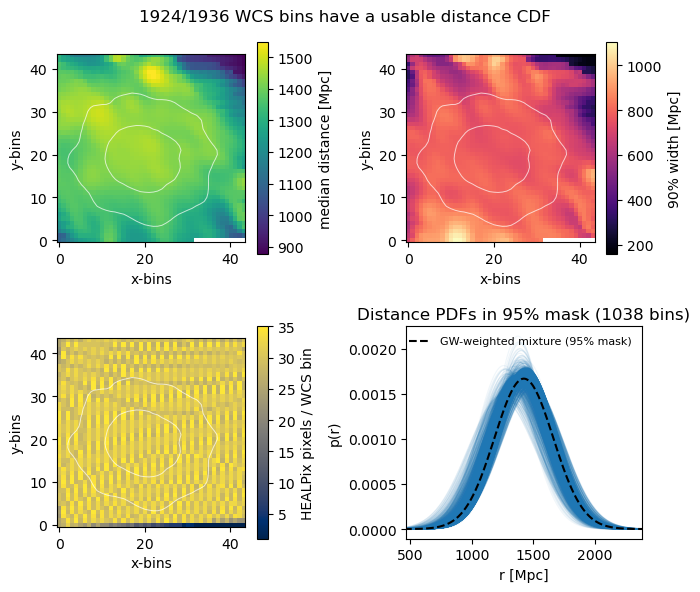

In [8]:
# --- Quantile maps + distance-prior summary plot ---
dist_med = utils.distance_map_from_cdf(r_grid, cdf_table, cdf_valid, q=0.5)
dist_lo  = utils.distance_map_from_cdf(r_grid, cdf_table, cdf_valid, q=0.05)
dist_hi  = utils.distance_map_from_cdf(r_grid, cdf_table, cdf_valid, q=0.95)

i_hot, j_hot = np.unravel_index(np.argmax(prob_gw_integrated), prob_gw_integrated.shape)
print(f"Hottest WCS bin ({i_hot},{j_hot}): "
      f"d = {dist_med[i_hot, j_hot]:.0f} [{dist_lo[i_hot, j_hot]:.0f}, "
      f"{dist_hi[i_hot, j_hot]:.0f}] Mpc (90% CI),  cdf_valid={cdf_valid[i_hot, j_hot]}")
print(f"LVK header DISTANCE: {meta_lvk_hp.get('distmean'):.2f}+-{meta_lvk_hp.get('diststd'):.2f}")

# pdf_gw_mask: GW-weighted mixture distance PDF restricted to the 95% mask --
# the reference curve reused below by the BKG animation, since the animated
# (F=0) injected positions are drawn from that same mask.
pdf_gw_mask = plotting.plot_distance_prior_summary(
    r_grid, cdf_table, cdf_valid, prob_gw_integrated, mask_threshold_95,
    dist_med, dist_lo, dist_hi, n_pix_per_bin,
    save_path=str(gwpaths.plot_path(source_name, "summary_distance_LVK.png")),
    pdf_bins="mask",
)

# Sky-marginalised distance posterior over the FULL GW map -- the canonical
# prior every flux<->luminosity conversion in Part 2 uses (the summary table,
# the final figure, and the 3D-sampler crosscheck), computed once here so
# they cannot drift apart into independently-derived versions of "the" prior.
cdf_marg, pdf_marg = simulate.marginal_distance_pdf(prob_gw_integrated, cdf_table, cdf_valid, r_grid)
mean_agg = np.trapezoid(r_grid * pdf_marg, r_grid)

### Reading the DL3 data and adding the background IRF
The `bkg_type` background model is added to each run's HDU table before building the observations.

In [9]:
# --- Load Data Store ---
data_store_real = DataStore.from_dir(dir_dl3)
print(f"Obs IDs in directory: {data_store_real.obs_ids}\n")

# --- Add Background IRF ---
data_store_real.hdu_table.remove_rows(data_store_real.hdu_table["HDU_TYPE"] == "bkg")  # avoid duplicates on re-run
for obs_id in obs_ids:
    data_store_real = utils.add_bkg(data_store_real, obs_id, dir_dl3, dim_bkg=3, bkg_type=bkg_type)
data_store_real.hdu_table = data_store_real.hdu_table.copy()

# --- Observations ---
obs_collection_real = data_store_real.get_observations(obs_id=obs_ids, required_irf=["aeff", "edisp", "psf"])
obs_table = data_store_real.obs_table[np.isin(data_store_real.obs_table["OBS_ID"], obs_ids)]
hdu_table = data_store_real.hdu_table[np.isin(data_store_real.hdu_table["OBS_ID"], obs_ids)]

print(f"Total livetime: {obs_table['LIVETIME'].to(u.min).sum():.2f}\n")
display(obs_table); display(hdu_table)

Obs IDs in directory: [17820 17821 17822 17823 17824 17825]

Total livetime: 93.15 min



OBS_ID,DATE-OBS,TIME-OBS,DATE-END,TIME-END,RA_PNT,DEC_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,RA_OBJ,DEC_OBJ,TSTART,TSTOP,ONTIME,TELAPSE,LIVETIME,DEADC,OBJECT,OBS_MODE,N_TELS,TELLIST,INSTRUME
,,,,,deg,deg,deg,deg,deg,deg,deg,s,s,s,s,s,,,,,,
int64,bytes10,bytes12,bytes10,bytes12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes9,bytes6,int64,bytes10,bytes10
17821,2024-06-16,02:57:34.658,2024-06-16,03:17:16.810,6.8951525047952895,45.82776183610452,60.33308804733734,29.666911952662655,50.87241146882353,7.69,45.67,1718506654.6583865,1718507836.8098843,1177.0634326934814,1182.1514978408827,1123.4850565625625,0.9544813179623505,S240615dg,WOBBLE,3,LST1_M1_M2,LST1_M1_M2
17822,2024-06-16,03:17:59.632,2024-06-16,03:37:38.863,7.462985518214153,46.22722746601868,57.162484179186706,32.837515820813294,51.07797375656371,7.69,45.67,1718507879.6318793,1718509058.8630166,1169.7947826385498,1179.2311372756924,1105.7800234869321,0.9452769322434247,S240615dg,WOBBLE,3,LST1_M1_M2,LST1_M1_M2
17823,2024-06-16,03:38:29.523,2024-06-16,03:58:04.605,7.502702596638403,45.41011221509676,53.75221902126912,36.24778097873088,52.61544198222221,7.69,45.67,1718509109.5227242,1718510284.6046517,1173.8554291725159,1175.0819275379104,1112.5598553005377,0.9477826891211066,S240615dg,WOBBLE,3,LST1_M1_M2,LST1_M1_M2
17824,2024-06-16,03:58:47.554,2024-06-16,04:18:28.881,8.025328824969337,45.82762323558363,50.54489456649123,39.45510543350877,52.39164790789783,7.69,45.67,1718510327.5544693,1718511508.8810978,1181.4114089012146,1181.3266284465801,1120.2192977835302,0.9482042321103055,S240615dg,WOBBLE,3,LST1_M1_M2,LST1_M1_M2
17825,2024-06-16,04:19:11.960,2024-06-16,04:38:51.901,6.916248681126189,45.811906444323064,46.21649488271295,43.78350511728705,52.450947187305914,7.69,45.67,1718511551.9603717,1718512731.900546,1180.1842045783997,1179.9401743412072,1126.9978251553625,0.9549338321791581,S240615dg,WOBBLE,3,LST1_M1_M2,LST1_M1_M2


OBS_ID,HDU_TYPE,HDU_CLASS,FILE_DIR,FILE_NAME,HDU_NAME,SIZE
int64,bytes8,bytes9,bytes1,bytes32,bytes17,int64
17821,events,events,.,dl3_MAGIC_LST-1.Run17821.fits.gz,EVENTS,505719
17821,gti,gti,.,dl3_MAGIC_LST-1.Run17821.fits.gz,GTI,505719
17821,pointing,pointing,.,dl3_MAGIC_LST-1.Run17821.fits.gz,POINTING,505719
17821,aeff,aeff_2d,.,dl3_MAGIC_LST-1.Run17821.fits.gz,EFFECTIVE AREA,505719
17821,edisp,edisp_2d,.,dl3_MAGIC_LST-1.Run17821.fits.gz,ENERGY DISPERSION,505719
17821,psf,psf_table,.,dl3_MAGIC_LST-1.Run17821.fits.gz,PSF,505719
17822,events,events,.,dl3_MAGIC_LST-1.Run17822.fits.gz,EVENTS,650268
17822,gti,gti,.,dl3_MAGIC_LST-1.Run17822.fits.gz,GTI,650268
17822,pointing,pointing,.,dl3_MAGIC_LST-1.Run17822.fits.gz,POINTING,650268


#### Showing summaries for all the data + IRFs inside the DL3

EVENTS SUMMARY:


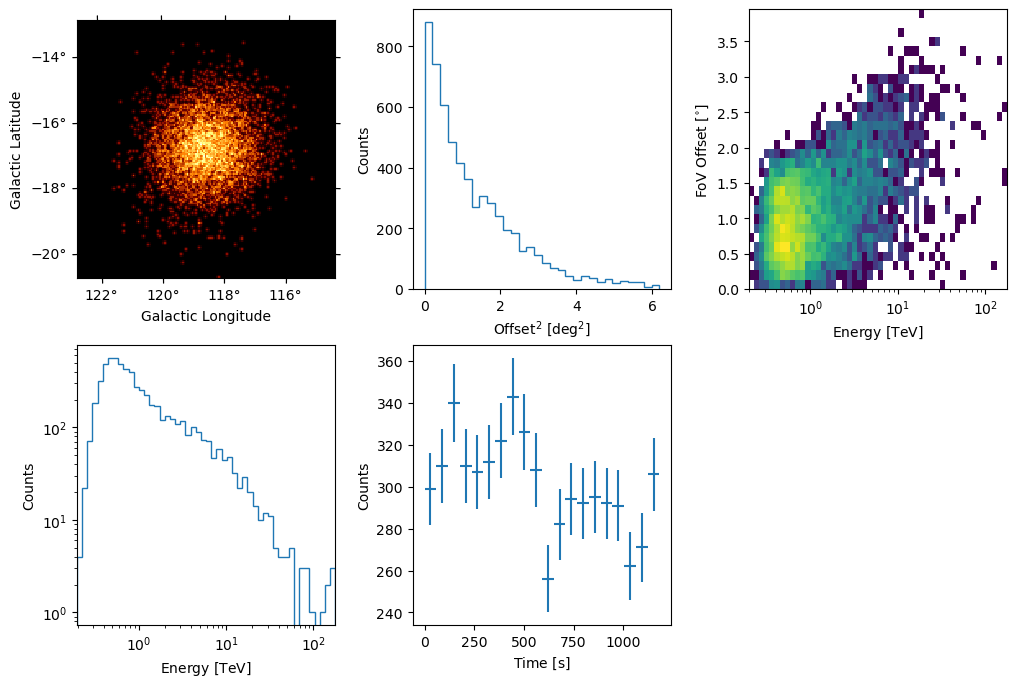

EFFECTIVE AREA SUMMARY:


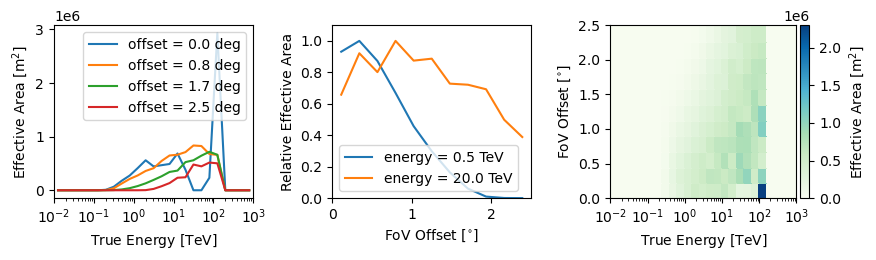

ENERGY DISPERSION SUMMARY:


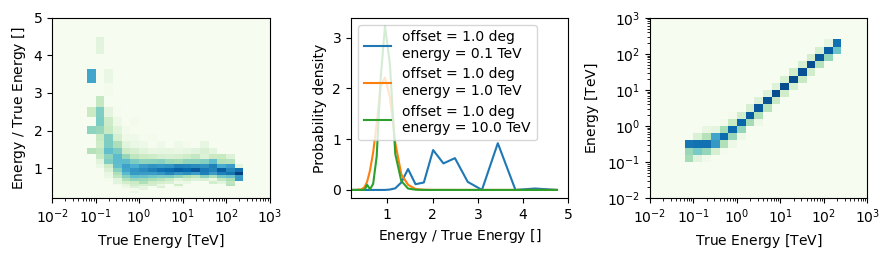

PSF SUMMARY:


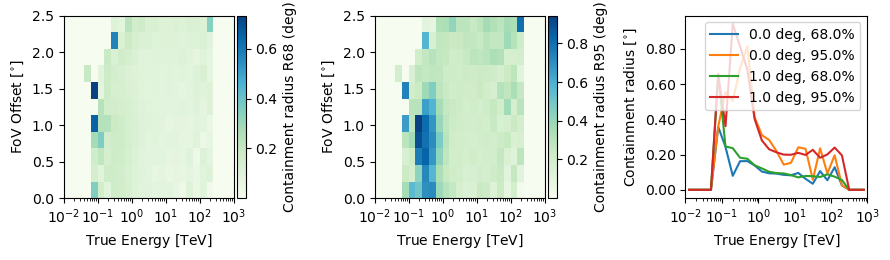

BACKGROUND SUMMARY:


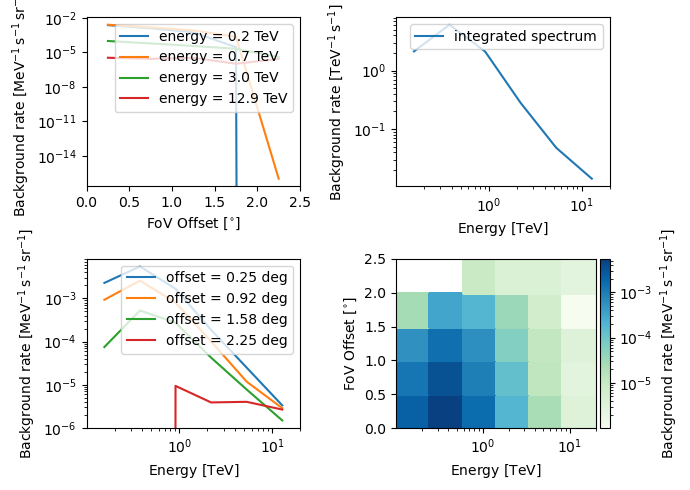

In [10]:
obs = obs_collection_real[0]
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    print("EVENTS SUMMARY:"); obs.events.peek(); plt.show()
    print("EFFECTIVE AREA SUMMARY:"); obs.aeff.peek(figsize=(9, 2.7)); plt.show()
    print("ENERGY DISPERSION SUMMARY:"); obs.edisp.peek(figsize=(9, 2.7)); plt.show()
    print("PSF SUMMARY:"); obs.psf.peek(figsize=(9, 2.7)); plt.show()
    print("BACKGROUND SUMMARY:"); obs.bkg.peek(figsize=(7, 5)); plt.show()

#### Running the pipeline on the real data
Per run: `MapDatasetMaker` → `SafeMaskMaker` (offset cut at `size_fov`) → `RingBackgroundMaker` [3]
(`ring_r_in`, `ring_width`), then stacked. Each run's ring background is kept and reused as the
background of the simulated dataset.

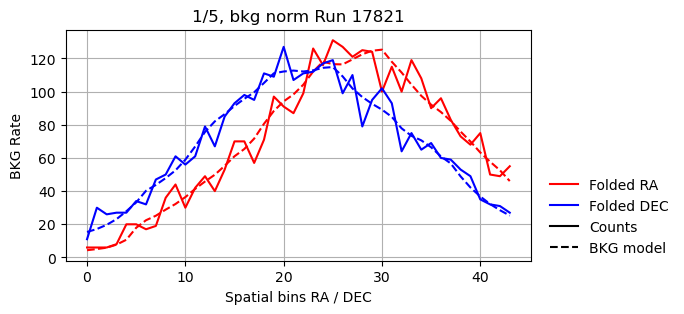

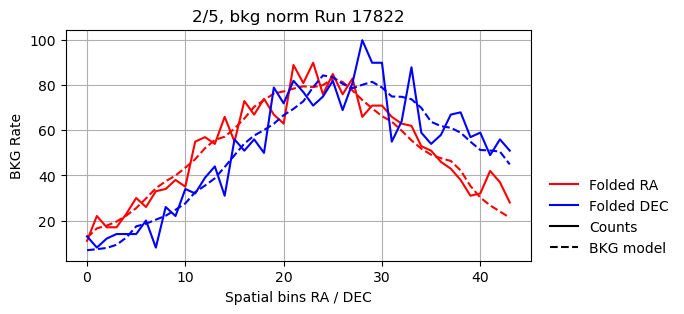

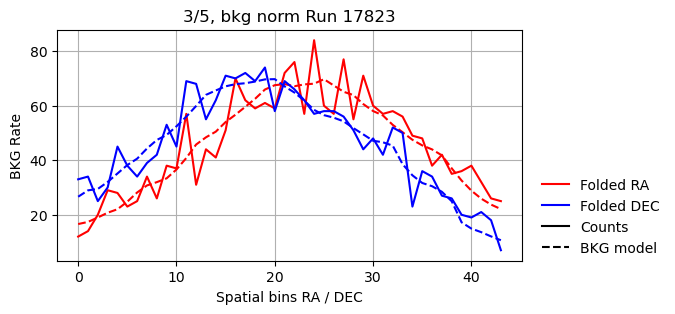

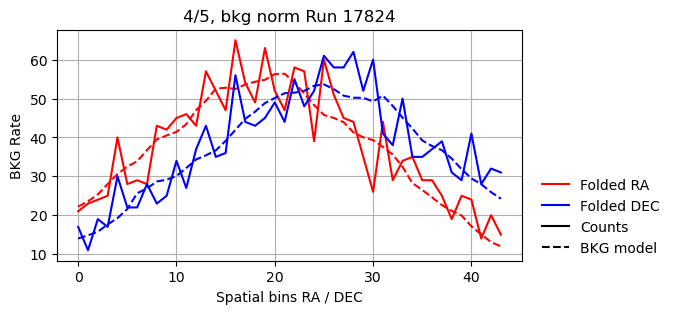

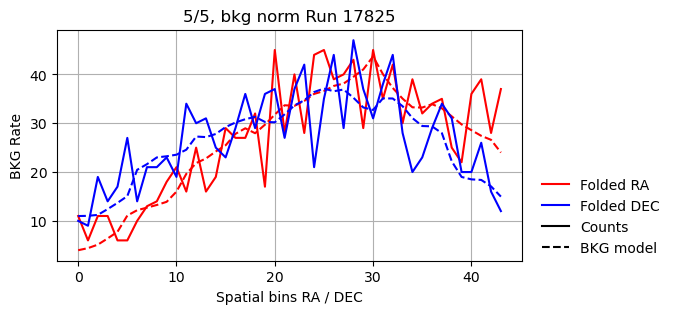

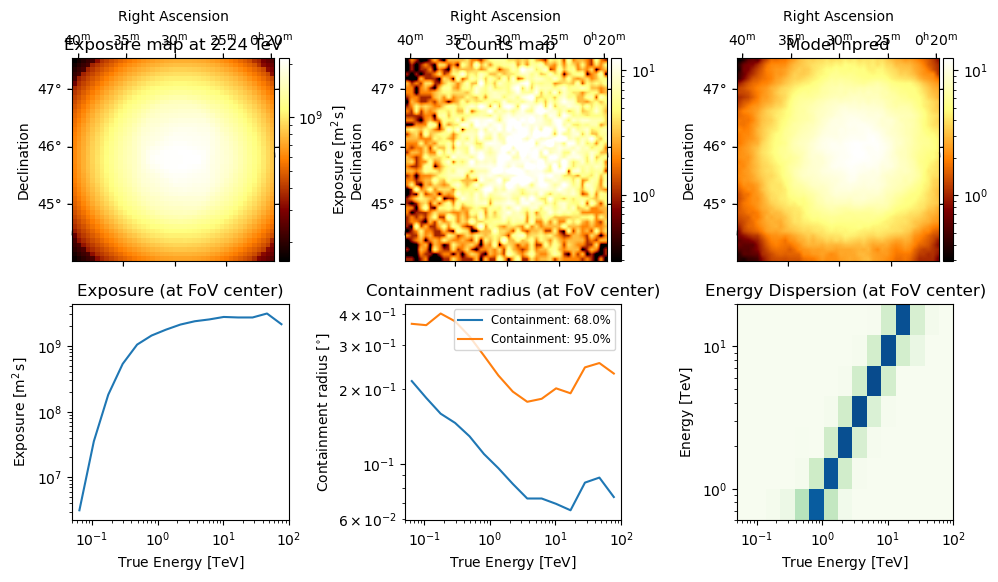

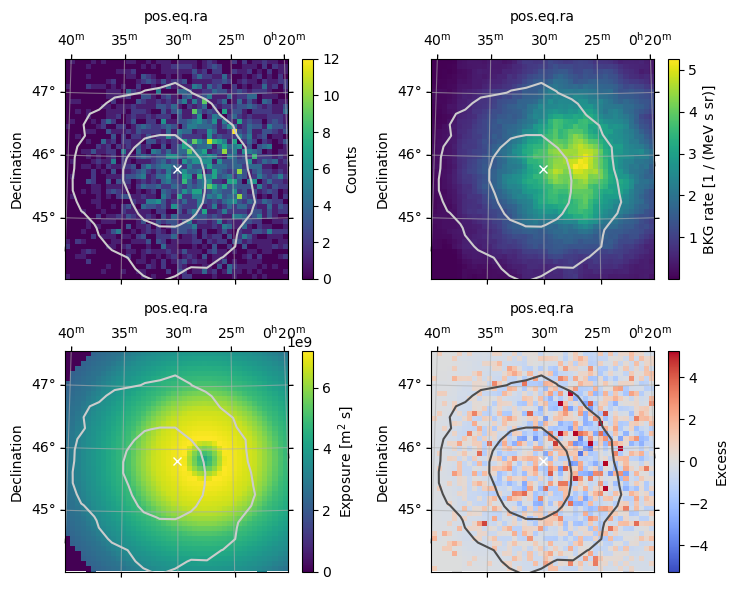

In [11]:
# --- Makers ---
maker = MapDatasetMaker(selection=["counts", "background", "psf", "edisp", "exposure"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=size_fov)
maker_ring = RingBackgroundMaker(r_in=ring_r_in, width=ring_width, exclusion_mask=exclusion_mask)

# --- Empty Datasets ---
dataset_empty = MapDataset.create(geom, energy_axis_true=axis_energy_true)
dataset_stacked_real = MapDataset.create(geom, energy_axis_true=axis_energy_true)

# --- Processing Loop ---
dataset_real, bkg_models = [], []
for i, obs in enumerate(obs_collection_real):
    dataset    = maker.run(dataset_empty.copy(), obs)
    dataset    = maker_safe_mask.run(dataset, obs)
    dataset_on_off = maker_ring.run(dataset)

    bkg_models.append(dataset_on_off.background.copy())
    dataset_real.append(dataset_on_off)
    dataset_stacked_real.stack(dataset_on_off)

    plotting.summary_folded_counts(dataset_on_off, bin_c_ra, obs, i, len(obs_collection_real))

datasets_all_real = Datasets(dataset_real)

# --- Summary Plots ---
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    dataset_stacked_real.peek(figsize=(10, 6))
plotting.summary_maps(
    dataset_real[0], geom, bin_edges_ra, bin_edges_dec,
    lvk_prob_2d, threshold_maps, source_coord, source_name
)

### Defining the estimators
* `ExcessMapEstimator`: used for $TS$ (here and in every realisation), as it is fast. It convolves the
  maps with a top-hat of `correlation_radius`, so its fluxes need the containment correction below.
* `TSMapEstimator`: full-PSF flux estimate; slower, stored in the `.pkl` for reference.

Both assume the same power law (`spectral_index`) and use the one-sided CL `n_sigma_ul`.

In [12]:
# --- Shared Config ---
energy_edges = [axis_energy.edges[0], axis_energy.edges[-1]]
n_sigma_ul   = norm.ppf(confidence_level)

spatial_model  = PointSpatialModel(lon_0=source_coord.ra, lat_0=source_coord.dec)
spectral_model = PowerLawSpectralModel(index=2)

# --- Estimators ---
excess_estimator = ExcessMapEstimator(
    correlation_radius    = correlation_radius,
    correlate_off         = True,
    spectral_model        = spectral_model,
    energy_edges          = energy_edges,
    sum_over_energy_groups= True,
    selection_optional    = ["ul"],
)
excess_estimator.n_sigma_ul = n_sigma_ul

ts_estimator = TSMapEstimator(
    model                 = SkyModel(spectral_model=PowerLawSpectralModel(),
                                     spatial_model=spatial_model),
    energy_edges          = energy_edges,
    sum_over_energy_groups= True,
    selection_optional    = ["ul"],
)
ts_estimator.n_sigma_ul = n_sigma_ul

### <span style="color:blue">Crosscheck: the flux &harr; luminosity conversion</span>

Everything downstream &mdash; the 2D flux limit, the 3D luminosity limit and the
comparison between them &mdash; rests on integrating the assumed power law over the
analysis band. For $dN/dE = \phi_0 (E/E_0)^{-\Gamma}$:

$$F_{\rm ph}=\phi_0 E_0\!\!\int_{x_1}^{x_2}\!\! x^{-\Gamma}dx,\qquad
F_E=\phi_0 E_0^2\!\!\int_{x_1}^{x_2}\!\! x^{1-\Gamma}dx,\qquad
L = 4\pi d_L^2 F_E (1+z)^{\Gamma-2}$$

with $x=E/E_0$. Two things are easy to get wrong and are checked explicitly here:

* $\Gamma = 2$ &mdash; the index this analysis uses &mdash; is **exactly the singular
  case** of the energy-flux integral. The $1/(2-\Gamma)$ form returns `inf`/`nan`
  there; it must be evaluated as $\phi_0 E_0^2\ln(E_2/E_1)$.
* $L$ is the isotropic-equivalent luminosity **in the analysis band**, not a
  bolometric luminosity. The previous version of `amplitude_from_luminosity`
  computed the right number but documented it as bolometric, which silently
  changes what the quoted limit means.

The $K$-correction $(1+z)^{\Gamma-2}$ is identically 1 at $\Gamma=2$, so band
luminosities are redshift-independent at this index &mdash; a useful anchor, verified
below along with round trips, quadrature and gammapy's own model.

In [13]:
if RUN_CROSSCHECKS:
    simulate.check_spectral_conversions(
        energy_edges = energy_edges,
        indices      = (1.5, 2.0, 2.5),
        amplitude    = 1e-12,
        distance     = 300 * u.Mpc,
    )

# What one amplitude actually means in this band, integrated properly:
print()
print(simulate.flux_point_from_amplitude(1e-12, energy_edges, index=spectral_index, e_ref=e_ref))

Spectral conversion crosschecks  |  band [0.600 TeV, 20.000 TeV]  |  phi0 = 1.00e-12

  Gamma = 1.5
    PASS  photon flux: analytic vs quad                  2.13477530e-12 vs 2.13477530e-12  (rel 1.89e-16)
    PASS  energy flux: analytic vs quad                  1.18482221e-11 vs 1.18482221e-11  (rel 1.36e-16)
    PASS  photon flux: analytic vs gammapy               2.13477530e-12 vs 2.13477530e-12  (rel 0.00e+00)
    PASS  energy flux: analytic vs gammapy               1.18482221e-11 vs 1.18482221e-11  (rel 0.00e+00)
    PASS  round trip phi0 -> L -> phi0                   1.00000000e-12 vs 1.00000000e-12  (rel 0.00e+00)
    PASS  round trip phi0 -> F_ph -> phi0                1.00000000e-12 vs 1.00000000e-12  (rel 0.00e+00)

  Gamma = 2.0
    PASS  photon flux: analytic vs quad                  1.61666667e-12 vs 1.61666667e-12  (rel 0.00e+00)
    PASS  energy flux: analytic vs quad                  5.61812513e-12 vs 5.61812513e-12  (rel 0.00e+00)
    PASS  photon flux: analytic vs ga

### Computing $\Lambda$ for the real data

Only the counts statistics are needed (no UL), which is much faster and is exactly what each
realisation computes. Per bin, $TS$ is the signed Cash likelihood ratio [1] summed over energy, and
$\Lambda$ is the maximum of $TS' = TS + 2\ln p_{\rm GW}$ over the 95% GW region (§4.2–4.3).

In [14]:
stats_real = convolved_map_dataset_counts_statistics(
    convolved_maps = _get_convolved_maps(
        dataset = dataset_stacked_real,
        kernel = excess_estimator.estimate_kernel(dataset_stacked_real),
        mask = excess_estimator.estimate_mask_default(dataset_stacked_real),
        correlate_off = excess_estimator.correlate_off
    ),
    stat_type = "cash" # "wstat" or "cash", cash works with OnOffMapDataset
)

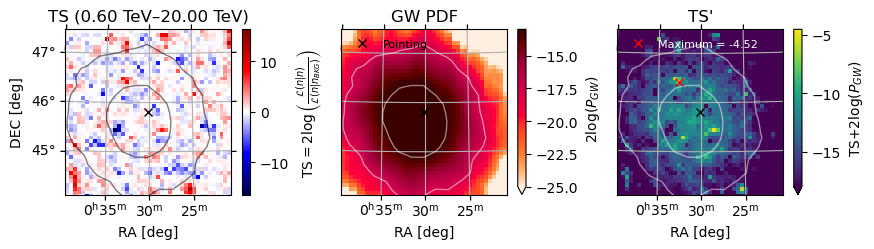

In [15]:
# --- Cash Statistics ---
n_on   = stats_real.n_on.sum(axis=0)
mu_bkg = stats_real.mu_bkg.sum(axis=0)

lik_alt  = cash(n_on, n_on)
lik_null = cash(n_on, mu_bkg)
ts_sign  = np.where((n_on - mu_bkg) >= 0.0, +1.0, -1.0)
ts       = np.where((lik_null - lik_alt) < 0.0, 0.0, lik_null - lik_alt) * ts_sign
ts2      = ts + 2 * np.log(prob_gw)

# --- GW-Weighted Maximum (95% region) ---
ts2_masked        = np.where(mask_threshold_95, ts2, np.nan)
ts2_argmax        = np.unravel_index(np.nanargmax(ts2_masked), ts2_masked.shape)
lambda_real       = np.nanmax(ts2_masked)
lambda_coord_real = SkyCoord(ra=bin_c_ra[ts2_argmax], dec=bin_c_dec[ts2_argmax], unit=u.deg, frame="icrs")

plotting.summary_ts_maps(
    geom, bin_c_ra, bin_c_dec, ts, log_gw, ts2, lvk_prob_2d, threshold_maps, source_coord,
    lambda_real, lambda_coord_real, axis_energy
)

### Simulation dataset from the real observations
From each real run we take the IRFs (effective area, energy dispersion, PSF, background), livetime,
reference time and pointing, and build an `Observation` with them. The resulting empty datasets
(one per run, plus their stack) have the real exposure and the real ring background; a realisation
only sets a source model and calls `.fake()` (§4.5).


Run 17821
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 18.72 min
 - Time Ref: 2024-06-16 02:57:34.658
 - Pointing: (RA=6.90, DEC=45.83) deg

Run 17822
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 18.43 min
 - Time Ref: 2024-06-16 03:17:59.632
 - Pointing: (RA=7.46, DEC=46.23) deg

Run 17823
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 18.54 min
 - Time Ref: 2024-06-16 03:38:29.523
 - Pointing: (RA=7.50, DEC=45.41) deg

Run 17824
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 18.67 min
 - Time Ref: 2024-06-16 03:58:47.554
 - Pointing: (RA=8.03, DEC=45.83) deg

Run 17825
 - IRFs:     ['aeff', 'edisp', 'psf', 'bkg']
 - Livetime: 18.78 min
 - Time Ref: 2024-06-16 04:19:11.960
 - Pointing: (RA=6.92, DEC=45.81) deg


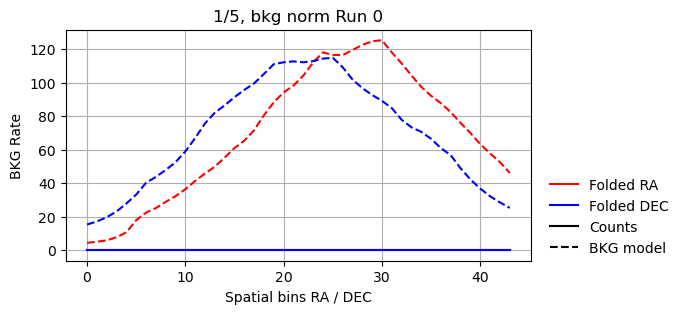

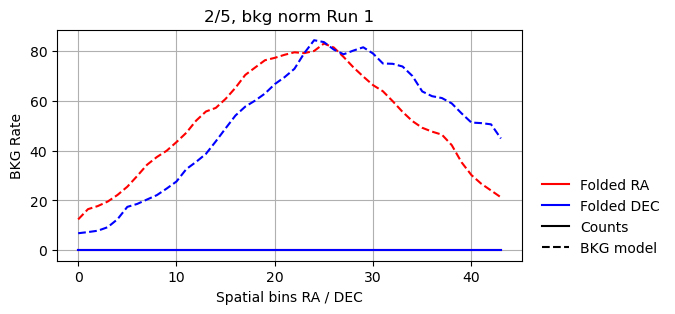

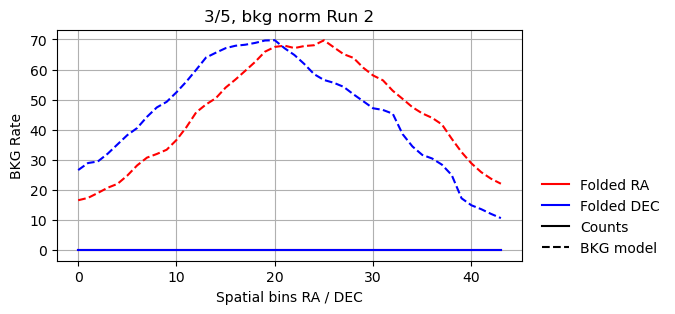

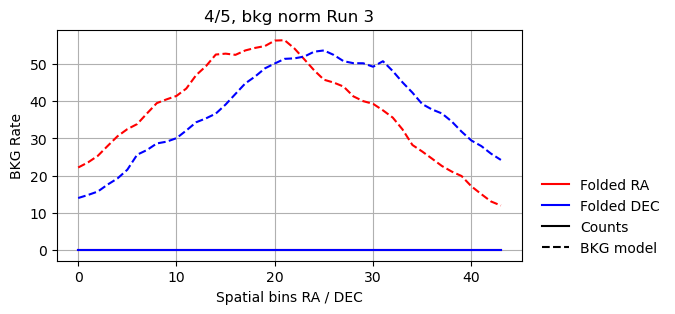

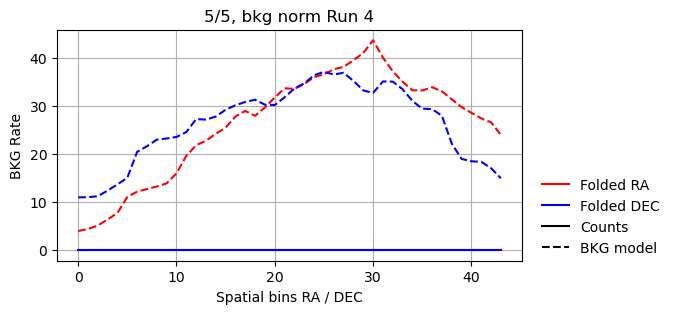

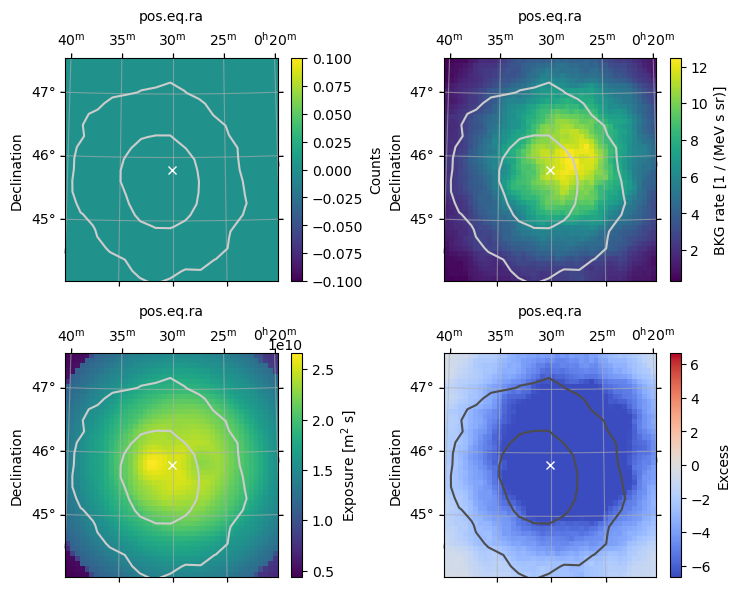

In [16]:
# --- Load IRFs per Observation ---
obs_irfs, obs_time_ref, obs_pointing, obs_livetime = [], [], [], []
for obs_id in obs_ids:
    hdu_tab = data_store_real.hdu_table[data_store_real.hdu_table["OBS_ID"] == obs_id]
    obs_tab = data_store_real.obs_table[data_store_real.obs_table["OBS_ID"] == obs_id]

    path_dl3 = os.path.join(dir_dl3, hdu_tab[hdu_tab["HDU_NAME"] == "EVENTS"]["FILE_NAME"][0])
    path_bkg = os.path.join(dir_dl3, hdu_tab[hdu_tab["HDU_NAME"] == "BACKGROUND"]["FILE_NAME"][0])

    irfs = load_irf_dict_from_file(path_dl3)
    irfs.update(load_irf_dict_from_file(path_bkg))
    obs_irfs.append(irfs)

    t_ref  = Time(f"{obs_tab['DATE-OBS'][0]} {obs_tab['TIME-OBS'][0]}", scale="utc")
    pnt    = SkyCoord(ra=obs_tab["RA_PNT"][0], dec=obs_tab["DEC_PNT"][0], unit=u.deg, frame="icrs")
    t_live = np.sum(obs_tab["LIVETIME"])
    obs_time_ref.append(t_ref);  obs_pointing.append(pnt);  obs_livetime.append(t_live)

    print(f"\nRun {obs_id}"
          f"\n - IRFs:     {list(irfs.keys())}"
          f"\n - Livetime: {t_live/60:.2f} min"
          f"\n - Time Ref: {t_ref}"
          f"\n - Pointing: (RA={obs_tab['RA_PNT'][0]:.2f}, DEC={obs_tab['DEC_PNT'][0]:.2f}) deg")

# --- Build Observations ---
observations = [
    Observation.create(
        obs_id         = f"{i}",
        pointing       = FixedPointingInfo(obs_pointing[i]),
        livetime       = obs_livetime[i] * u.s,
        irfs           = obs_irfs[i],
        location       = observing_location,
        reference_time = obs_time_ref[i],
    ) for i in range(len(obs_irfs))
]

# --- Simulate Datasets ---
maker = MapDatasetMaker(selection=["background", "psf", "edisp", "exposure"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=size_fov)
dataset_empty = MapDataset.create(geom, energy_axis_true=axis_energy_true)
dataset_stacked_simulated = MapDataset.create(geom, energy_axis_true=axis_energy_true)

dataset_simulated = []
for i, obs in enumerate(observations):
    dataset = maker_safe_mask.run(maker.run(dataset_empty.copy(), obs), obs)
    dataset.background = bkg_models[i]
    dataset_simulated.append(dataset)
    dataset_stacked_simulated.stack(dataset)
    plotting.summary_folded_counts(dataset, bin_c_ra, obs, i, len(observations))

dataset_all_simulated = Datasets(dataset_simulated)
plotting.summary_maps(
    dataset_stacked_simulated, geom, bin_edges_ra, bin_edges_dec,
    lvk_prob_2d, threshold_maps, source_coord, source_name
)

### Containment correction for the `ExcessMapEstimator`
A bright point source is injected at the centre `nsim_test` times; the median ratio of the
estimated to the true flux is the fraction of the PSF inside the top-hat, used to correct the sky-map
fluxes below (§4.6).

Test amplitude 1.0e-08 cm-2 s-1 TeV-1 @ 1 TeV — 100/100

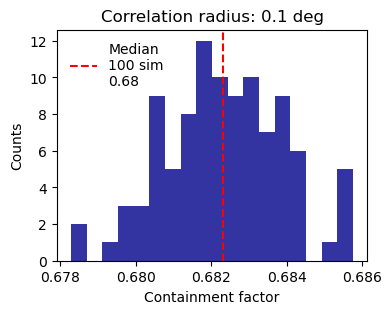

CPU times: user 41.1 s, sys: 1.85 s, total: 43 s
Wall time: 43.3 s


In [17]:
%%time
# --- Source Model ---
nsim_test     = 100
test_amplitud = 1e-8  # cm-2 s-1 TeV-1 @ 1 TeV
model_source  = Models([SkyModel(
    spatial_model  = PointSpatialModel.from_position(coord_center),
    spectral_model = PowerLawSpectralModel(index=2, amplitude=f"{test_amplitud} cm-2 s-1 TeV-1", reference="1 TeV"),
    temporal_model = ConstantTemporalModel(),
    name           = "model-simulated-test",
)])
true_flux_int = model_source[0].spectral_model.integral(
    excess_estimator.energy_edges[0], excess_estimator.energy_edges[-1]
)

# --- Containment Loop ---
containment_fluxes_test = []
for k in range(nsim_test):
    dataset_test = copy.deepcopy(dataset_stacked_simulated)
    dataset_test.models = model_source
    dataset_test.fake()
    dataset_test.models = None
    print(f"Test amplitude {test_amplitud:.1e} cm-2 s-1 TeV-1 @ 1 TeV — {k+1}/{nsim_test}", end="\r")

    result_test    = excess_estimator.run(dataset=dataset_test)
    central_index  = (0, len(result_test.flux.data[0][0])//2, len(result_test.flux.data[0].T[0])//2)
    containment_fluxes_test.append(result_test.flux.data[central_index] / (u.cm**2) / u.s / true_flux_int)

# --- Plot ---
containment_factor = np.median(containment_fluxes_test)
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(containment_fluxes_test, 18, color="darkblue", alpha=0.8)
ax.axvline(containment_factor, color="r", ls="--", label=f"Median\n{nsim_test} sim\n{containment_factor:.2f}")
ax.set(xlabel="Containment factor", ylabel="Counts", title=f"Correlation radius: {correlation_radius}")
ax.legend(frameon=False)
plt.show()

### Sky-map ULs for the real data
Per-pixel flux and flux UL from the `ExcessMapEstimator`, divided by the containment factor. These
carry no trials factor and serve as a sanity reference for the global limit (§7.7).

In [18]:
# --- Excess Map ---
print("Running Excess Map Estimator...")
maps_real = excess_estimator.run(dataset_stacked_real)

# --- Flux Arrays ---
def _masked(arr): return np.where(mask_threshold_95, arr, np.nan)
def _masked_array(*arrays):
    # compressed arrays: only pixels where mask_threshold_95 is True and not NaN
    flat_mask = mask_threshold_95.ravel()
    results = []
    for arr in arrays:
        flat = arr.ravel()
        valid = flat_mask & ~np.isnan(flat)
        results.append(flat[valid])
    return np.array(results)

flux_uls = maps_real["flux_ul"].data.ravel() / containment_factor
fluxs = maps_real["flux"].data.ravel()    / containment_factor
flux_uls_95 = _masked(maps_real["flux_ul"].data).ravel() / containment_factor
fluxs_95 = _masked(maps_real["flux"].data).ravel()    / containment_factor

sigs = maps_real["sqrt_ts"].data.ravel()
sigs_95 = _masked_array(maps_real["sqrt_ts"].data).ravel()

Running Excess Map Estimator...


#### Flux and flux-UL distributions in the field of view and in the 95% region

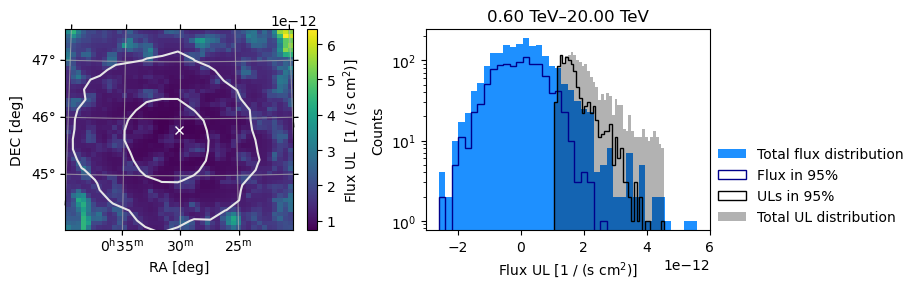

In [19]:
plotting.plot_flux_ul_map_and_distributions(
    geom, bin_edges_ra, bin_edges_dec, maps_real["flux_ul"].smooth(0.5).data[0],
    source_coord, source_name, fluxs, fluxs_95, flux_uls, flux_uls_95,
    lvk_prob_2d, threshold_maps, energy_edges,
)

#### Significance map and distribution

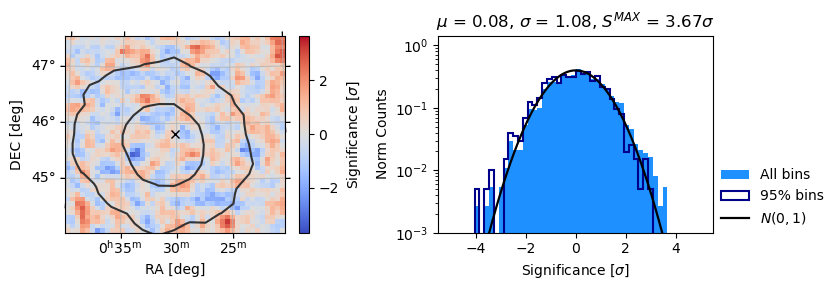

In [20]:
_sqrt_ts_raw = np.array(maps_real["sqrt_ts"].data)
plotting.plot_significance_map_and_distribution(
    geom, bin_edges_ra, bin_edges_dec, maps_real["sqrt_ts"].smooth(0.5).data[0],
    vmin=-_sqrt_ts_raw.max(), vmax=_sqrt_ts_raw.max(),
    source_coord=source_coord, source_name=source_name, sigs=sigs, sigs_95=sigs_95,
    lvk_prob_2d=lvk_prob_2d, threshold_maps=threshold_maps,
)

### Storing the simulation inputs

Two `.pkl` files are written to `TMP_DIR` (the simulated dataset, used downstream, and the real one):
* the estimators, the analysis band, `spectral_index` and `e_ref`
* the stacked dataset to simulate and, for the emission model, each run's dataset and GTIs
  (seconds since the merger)
* the GW map on the WCS grid, the 95% mask, the distance grid and per-bin CDF table
* the containment factor

`simulate.validate_simulation_input` then checks the stored input for both the 2D and 3D modes,
so a malformed input fails here rather than thousands of realisations later.

In [21]:
type_obs = "mono" if "mono" in dir_dl3.lower() else "stereo" if "stereo" in dir_dl3.lower() else "unknown"

_pkl_base = dict(
    excess_estimator   = excess_estimator,
    ts_estimator       = ts_estimator,
    prob_gw            = prob_gw,
    lvk_prob_hp        = lvk_prob_hp,
    mask_threshold_95  = mask_threshold_95,
    containment_factor = containment_factor,
    e_min              = e_min,
    e_max              = e_max,
    energy_edges       = energy_edges,   # analysis band; the 3D pipeline needs it
    spectral_index     = spectral_index, # assumed shape, stored so it cannot drift
    e_ref              = e_ref,
    r_grid             = r_grid,         # 3D: distance grid [Mpc]
    cdf_table          = cdf_table,      # 3D: per-WCS-bin marginal distance CDF
    cdf_valid          = cdf_valid,      # 3D: whether a bin has a usable CDF
    type_obs           = type_obs,
    source_name        = source_name,
)
_pkl_stem = os.path.join(str(gwpaths.TMP_DIR), gwpaths.run_stem(
    source_name, type_obs, e_min.value, e_max.value, bkg_type,
    correlation_radius.value, binsz, use_dirac_delta=USE_DIRAC_DELTA))

path_pkl      = f"{_pkl_stem}.pkl"       # simulated dataset (used downstream)
path_pkl_real = f"{_pkl_stem}_real.pkl"  # real dataset

# Per-run inputs of the emission-model injection (Part 2): each run's own simulated
# dataset (exposure, PSF, edisp, background, safe mask) and its real GTIs in seconds
# since the merger. The model is averaged over each run's GTIs and folded through that
# run's IRFs, so a light curve that fades between runs is weighted correctly. Only the
# simulated .pkl needs them.
run_gti_s  = [simulate.gti_seconds_since(obs.gti, t_merger) for obs in obs_collection_real]
_pkl_model = dict(datasets_runs=dataset_simulated, run_gti_s=run_gti_s, t_merger_iso=t_merger.isot)
for _id, _g in zip(obs_ids, run_gti_s):
    print(f"Run {_id}: {_g[0, 0] / 3600:.2f}-{_g[-1, 1] / 3600:.2f} h after the merger "
          f"({len(_g)} GTI interval(s), {np.diff(_g, axis=1).sum() / 60:.1f} min)")

for path, dataset, extra in [(path_pkl, dataset_stacked_simulated, _pkl_model),
                             (path_pkl_real, dataset_stacked_real, {})]:
    with open(path, "wb") as f:
        pickle.dump({**_pkl_base, "dataset": dataset, **extra}, f)

# --- CROSSCHECK: fail here, not 5000 iterations later ----------------------
# Shape mismatches between the GW map and the WCS geometry, a transposed
# cdf_table, an empty 95% mask, a zero containment factor or a distance grid
# that truncates the posterior are all silent at write time and catastrophic
# (or, worse, quietly wrong) at simulation time.
print("\n--- Validating the stored input ---")
info_2d = simulate.validate_simulation_input({**_pkl_base, "dataset": dataset_stacked_simulated}, mode="2d")
info_3d = simulate.validate_simulation_input({**_pkl_base, "dataset": dataset_stacked_simulated}, mode="3d")

Run 17821: 15.35-15.67 h after the merger (1 GTI interval(s), 19.7 min)
Run 17822: 15.69-16.01 h after the merger (1 GTI interval(s), 19.7 min)
Run 17823: 16.03-16.35 h after the merger (1 GTI interval(s), 19.6 min)
Run 17824: 16.37-16.69 h after the merger (1 GTI interval(s), 19.7 min)
Run 17825: 16.71-17.03 h after the merger (1 GTI interval(s), 19.7 min)

--- Validating the stored input ---
  Input OK [2d]: grid (44, 44),  mask 1038 px (53.6%),  GW prob in mask 95.0% of FoV total 98.9%,  containment 0.682
  Input OK [3d]: grid (44, 44),  mask 1038 px (53.6%),  GW prob in mask 95.0% of FoV total 98.9%,  containment 0.682
             distance grid 1000 pts [1, 10000] Mpc,  1924 valid bins carrying 100.0% of the sky probability


## Part 2 — Simulations

Background-only realisations first (the observation's significance and the reference
$\Lambda^\star$), then the 2D flux limit, the 3D luminosity limit, and the 3D limit with the emission
model.

With `UL_METHOD = "fit"` (default) each limit comes from `gwuls.simulate.run_fit_ul[_3d]`: every
realisation gets its own injected strength $x_i$, and the detection probability
$P(\Lambda > \Lambda^\star \mid x)$ is fitted by maximum likelihood with a probit in $\log x$, whose
no-signal floor is pinned by the background-only sample. The limit is where the fit crosses the CL;
its MC uncertainty comes from the likelihood profile. A first batch spans the whole bracket, later
batches sit around the limit, and each batch runs in parallel across `N_JOBS` processes. The
simulated rounds are cached, so an interrupted run resumes. `UL_METHOD = "bisect"` runs the
bisection (`run_iterative_ul[_3d]`) instead (§7.3–7.4).

### Background-only simulations

In [22]:
%%time
# --- Config ---
compute_uls   = False
amplitude_bkg = 0.0

_stem = gwpaths.run_stem(source_name, type_obs, e_min.value, e_max.value, bkg_type,
                         correlation_radius.value, binsz, use_dirac_delta=USE_DIRAC_DELTA)
_ext  = "extended" if compute_uls else ""
path_results_bkg = os.path.join(str(gwpaths.RESULTS_DIR), f"{_stem}_N{n_sim_bkg}_f{amplitude_bkg}_{_ext}.npz")

# --- Simulate or Load ---
if not os.path.exists(path_results_bkg) or OVERWRITE_RESULTS:
    simulate.perform_n_simulations(
        n_sim          = n_sim_bkg,
        amplitude      = amplitude_bkg,
        file_input     = path_pkl,
        file_output    = path_results_bkg,
        compute_uls    = compute_uls,
        spectral_index = spectral_index,
        e_ref          = e_ref,
        seed           = seed_fake,
        position_seed  = seed_positions,
        store_ts_maps  = True,   # needed by the per-pixel and TS' plots below
        store_stats    = True,
        n_jobs         = N_JOBS,
    )
else:
    print("Data already exists")

# --- Load Results ---
print(f"\nLoading for N={n_sim_bkg}...\n")
data_bkg = np.load(path_results_bkg, allow_pickle=True)

lambda_bkg, lambda_ra_bkg, lambda_dec_bkg = data_bkg["lambda_data"], data_bkg["lambda_ra"],  data_bkg["lambda_dec"]
tsmax_bkg, tsmax_ra_bkg, tsmax_dec_bkg    = data_bkg["tsmax"], data_bkg["tsmax_ra"], data_bkg["tsmax_dec"]
f_ra_bkg, f_dec_bkg = data_bkg["f_ra"], data_bkg["f_dec"]
ts_dist, ts2_dist   = data_bkg["ts_dist"], data_bkg["ts2_dist"]

if compute_uls:
    ulmax_bkg, ul_dist = data_bkg["ulmax"], data_bkg["ul_dist"]
    ulmax_ra_bkg, ulmax_dec_bkg = data_bkg["ulmax_ra"], data_bkg["ulmax_dec"]

# --- CROSSCHECK: is the background Lambda distribution self-consistent? ----
# With amplitude = 0 these realisations contain background only, so:
#   * Lambda should be a stable statistic -- split the sample in half and the
#     two medians should agree to within their MC error,
#   * the observed p-value has a binomial error that bounds how precisely the
#     significance can be quoted at all.
_h1, _h2 = np.array_split(np.asarray(lambda_bkg, dtype=float), 2)
_p       = np.mean(np.asarray(lambda_bkg) > lambda_real)
_p_err   = np.sqrt(max(_p * (1 - _p), 1e-12) / len(lambda_bkg))
print(f"BKG Lambda: median {np.median(lambda_bkg):.3f}  "
      f"(half-sample medians {np.median(_h1):.3f} / {np.median(_h2):.3f})")
print(f"p-value     {_p:.4f} +- {_p_err:.4f} (binomial, N={len(lambda_bkg)})  "
      f"-> significance {norm.ppf(1 - _p):+.2f} sigma "
      f"[{norm.ppf(1 - min(_p + _p_err, 0.999)):+.2f}, {norm.ppf(1 - max(_p - _p_err, 1e-4)):+.2f}]")
if _p in (0.0, 1.0):
    print("  NOTE: the p-value saturates the simulation sample; the significance is "
          f"only bounded, not measured (|sigma| > {abs(norm.ppf(1/len(lambda_bkg))):.2f}).")

Data already exists

Loading for N=5000...

BKG Lambda: median -4.074  (half-sample medians -4.062 / -4.080)
p-value     0.5922 +- 0.0069 (binomial, N=5000)  -> significance -0.23 sigma [-0.25, -0.22]
CPU times: user 176 ms, sys: 265 ms, total: 441 ms
Wall time: 661 ms


From the background-only $\Lambda$ distribution (§4.4):
* `p_value`: fraction of realisations above the observed $\Lambda$,
* `significance`: the p-value as a one-sided Gaussian significance,
* `lambda_bkg_m`: the background median, the reference $\Lambda^\star$ if the data under-fluctuate.

#### Crosscheck plot + background $\Lambda$ distribution

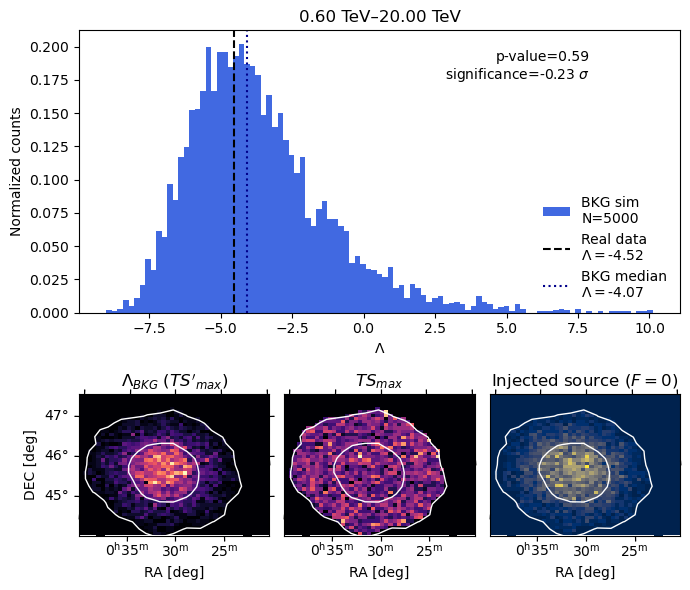

In [23]:
# --- Statistics ---
p_value      = np.mean(lambda_bkg > lambda_real)
significance = norm.ppf(1 - p_value)
lambda_bkg_m = np.median(lambda_bkg)

# --- Sky Maps ---
def _fill_map(geom_image, lon, lat):
    m = Map.from_geom(geom=geom_image)
    m.fill_by_coord({"lon": lon * u.deg, "lat": lat * u.deg})
    return m

map_lambda_bkg = _fill_map(geom_image, lambda_ra_bkg,  lambda_dec_bkg)
map_ts_bkg     = _fill_map(geom_image, tsmax_ra_bkg,   tsmax_dec_bkg)
map_source_sim = _fill_map(geom_image, f_ra_bkg,        f_dec_bkg)
if compute_uls:
    map_ul_bkg = _fill_map(geom_image, ulmax_ra_bkg, ulmax_dec_bkg)

# --- Lambda Bins ---
nbins_lambda = 100
min_l_bkg, max_l_bkg = lambda_bkg.min(), lambda_bkg.max()
bins_lambda = np.linspace(min_l_bkg, max_l_bkg, nbins_lambda)

plotting.summary_bkg_simulations(
    geom, bin_edges_ra, bin_edges_dec, lvk_prob_2d, threshold_maps,
    lambda_bkg, lambda_real, lambda_bkg_m, p_value, significance,
    map_lambda_bkg, map_ts_bkg, map_source_sim, energy_edges, bins_lambda
)

In [24]:
# dist_anim = plotting.animate_bkg_simulations(
#     geom, geom_image, bin_edges_ra, bin_edges_dec, bin_c_ra, bin_c_dec,
#     r_grid, cdf_table, cdf_valid, f_ra_bkg, f_dec_bkg,
#     lambda_bkg, lambda_ra_bkg, lambda_dec_bkg, lambda_real, bins_lambda,
#     threshold_maps, lvk_prob_2d, energy_edges,
#     path_gif=str(gwpaths.plot_path(source_name, "bkg_simulations_anim.gif")),
#     sampling_seed=seed_sampling, pdf_gw_mask=pdf_gw_mask,
# )

#### Crosscheck: n-on of random pixels, real data against the background realisations

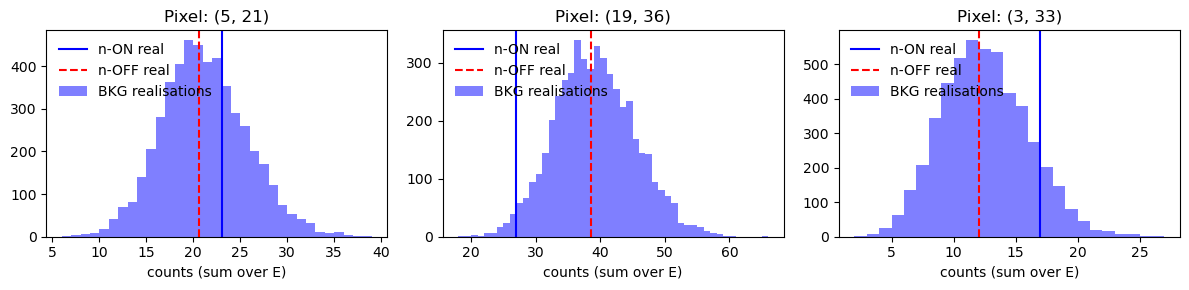

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))

for ax in axes:
    random_pixel = (
        np.random.randint(0, bin_edges_ra.shape[0] - 1), np.random.randint(0, bin_edges_ra.shape[1] - 1),
    )
    n_on_real = stats_real.n_on.sum(axis=0)[random_pixel]
    n_off_real = stats_real.n_bkg.sum(axis=0)[random_pixel]
    n_on_bkg = [s.n_on.sum(axis=0)[random_pixel] for s in data_bkg["stats"]]
    bin_edges = np.arange(min(n_on_bkg), max(n_on_bkg) + 2, 1)

    ax.axvline(n_on_real, color="b", ls="-", label="n-ON real")
    ax.axvline(n_off_real, color="r", ls="--", label="n-OFF real")
    ax.hist(n_on_bkg, bins=bin_edges, color="b", alpha=0.5, label="BKG realisations")
    ax.set(title=f"Pixel: {random_pixel}", xlabel="counts (sum over E)")
    ax.legend(frameon=False, loc=2)

plt.tight_layout()
plt.show()

### 2D flux upper limit
A Γ = `spectral_index` power law at fixed amplitude $\phi_0$, injected at a position drawn from the
GW probability inside the 95% region (§6.3). The limit is therefore conditional on the source lying
in the observed part of that region. Method: `UL_METHOD` (fit or bisection), or the amplitude grid
on Slurm if `USE_ITERATIVE_ULS = False`.

In [26]:
# --- Shared Config ---
amplitudes = np.logspace(-13, -10, 150)
compute_uls_f = False

precision = 0.02    # bisection only: bracket width to stop on, in dex
frac_tol  = 0.005   # bisection only: |frac - CL| tolerance; automatically widened to 2x the
                    # binomial MC error, since with N = n_sim_flux the noise on
                    # `frac` alone is sqrt(cl(1-cl)/N) and a tighter request can
                    # never be met (it just burns every iteration).

def _results_path(amplitude):
    ext = "extended" if compute_uls_f else ""
    stem = gwpaths.run_stem(source_name, type_obs, e_min.value, e_max.value, bkg_type,
                            correlation_radius.value, binsz, use_dirac_delta=USE_DIRAC_DELTA)
    return os.path.join(str(gwpaths.RESULTS_DIR), f"{stem}_N{n_sim_flux}_f{amplitude}_{ext}.npz")

# --- Non-Iterative: Submit Slurm Jobs (2D comparison baseline for this 3D notebook) ---
if not USE_ITERATIVE_ULS:
    for amplitude in amplitudes:
        path_results_f = _results_path(amplitude)
        if os.path.exists(path_results_f) and not OVERWRITE_RESULTS:
            print(f"Amplitude {amplitude:.2e} - already exists, skipping")
            continue
        if os.path.exists(path_results_f):
            print(f"Amplitude {amplitude:.2e} - overwriting")
        slurm.submit_simulation_job(
            n_sim_flux, amplitude, path_pkl, path_results_f,
            mode="2d", spectral_index=spectral_index,
            compute_uls=compute_uls_f, job_name=f"simulate_{source_name}",
        )

# --- Non-Iterative: Load Results & Compute UL ---
if not USE_ITERATIVE_ULS:
    lambda_f, amplitudes_found = [], []
    for amplitude in amplitudes:
        path_results_f = _results_path(amplitude)
        if not os.path.exists(path_results_f):
            continue
        lambda_f.append(np.load(path_results_f, allow_pickle=True)["lambda_data"])
        amplitudes_found.append(amplitude)
    amplitudes_found = np.array(amplitudes_found)

    # Grid UL: the amplitude at which the fraction above target crosses the CL,
    # interpolated (with its MC error) rather than snapped to the nearest grid
    # point -- the same estimator the bisection uses, so the two modes agree.
    _target = lambda_bkg_m if significance < 0 else lambda_real
    _frac   = np.array([np.mean(l > _target) for l in lambda_f])
    _n      = np.array([len(l) for l in lambda_f])
    amp_ul, _amp_lo1s, _amp_hi1s, _slope = simulate._interpolate_crossing(
        amplitudes_found, _frac, _n, confidence_level)
    if not np.isfinite(amp_ul):
        print("Warning: the amplitude grid never crosses the confidence level.")
        flux_ul = flux_diff_ul = None
    else:
        _fp_grid     = simulate.flux_point_from_amplitude(amp_ul, energy_edges, spectral_index, e_ref)
        flux_ul      = _fp_grid.photon_flux
        flux_diff_ul = _fp_grid.energy_flux
    cache = {"amp_ul": amp_ul, "flux_ul": flux_ul, "flux_diff_ul": flux_diff_ul,
             "hist_amp": list(amplitudes_found), "hist_frac": list(_frac),
             "hist_err": list(np.sqrt(_frac * (1 - _frac) / _n)),
             "x_ul_lo_1sigma": _amp_lo1s, "x_ul_hi_1sigma": _amp_hi1s,
             "lambda_cache": {f"{a:.6e}": l for a, l in zip(amplitudes_found, lambda_f)}}

# --- Iterative UL: curve fit (default) or bisection ---
else:
    _iter_stem = gwpaths.run_stem(source_name, type_obs, e_min.value, e_max.value, bkg_type,
                                  correlation_radius.value, binsz, use_dirac_delta=USE_DIRAC_DELTA)
    _iter_cache = os.path.join(str(gwpaths.TMP_DIR), (
        f"{_iter_stem}_fitul_prec{ul_precision}_max{ul_max_sims}.pkl" if UL_METHOD == "fit" else
        f"{_iter_stem}_iterative_nsim{n_sim_flux}_prec{precision}_fractol{frac_tol}.pkl"))
    # The fit keeps every simulated round here and reuses it on a rerun (e.g. after a crash).
    # The name pins what the realisations depend on -- the input .pkl (its modification
    # time), the spectrum and the seeds -- and not the target or the bracket, which only
    # decide where new realisations go.
    _fit_rounds_2d = os.path.join(str(gwpaths.TMP_DIR), (
        f"{_iter_stem}_fitul_rounds_idx{spectral_index}_seed{seed_fit}_{seed_positions}"
        f"_pkl{int(os.path.getmtime(path_pkl))}.pkl"))

    if os.path.exists(_iter_cache) and not OVERWRITE_RESULTS:
        print("Loading iterative UL cache...")
        with open(_iter_cache, "rb") as f:
            cache = pickle.load(f)
    else:
        if UL_METHOD == "fit":
            cache = simulate.run_fit_ul(
                path_pkl       = path_pkl,
                lambda_real    = lambda_real,
                lambda_bkg     = lambda_bkg,
                lambda_bkg_m   = lambda_bkg_m,
                significance   = significance,
                energy_edges   = energy_edges,
                cl             = confidence_level,
                amp_lo         = 1e-13,     # span of the first batch; checked after it
                amp_hi         = 1e-10,
                n_scout        = ul_n_scout,
                n_refine       = ul_n_refine,
                precision      = ul_precision,
                max_sims       = ul_max_sims,
                cache_path     = _fit_rounds_2d,
                spectral_index = spectral_index,
                e_ref          = e_ref,
                seed           = seed_fit,
                position_seed  = seed_positions,
                n_jobs         = N_JOBS,
            )
        else:
            _n_sim_2d = (simulate.geometric_n_sim_schedule(max(50, n_sim_flux // 8), n_sim_flux)
                         if USE_DYNAMIC_N_SIM else n_sim_flux)
            cache = simulate.run_iterative_ul(
                path_pkl       = path_pkl,
                lambda_real    = lambda_real,
                lambda_bkg     = lambda_bkg,
                lambda_bkg_m   = lambda_bkg_m,
                significance   = significance,
                p_value        = p_value,
                energy_edges   = energy_edges,
                cl             = confidence_level,
                n_sim          = _n_sim_2d,
                precision      = precision,
                frac_tol       = frac_tol,
                amp_lo         = 1e-13,
                amp_hi         = 1e-10,
                max_iter       = 20,
                spectral_index = spectral_index,
                e_ref          = e_ref,
                seed           = seed_fake,
                position_seed  = seed_positions,
                check_bracket  = True, # verify the crossing is inside [amp_lo, amp_hi]
                make_plots     = True,
                n_jobs         = N_JOBS,
            )
        with open(_iter_cache, "wb") as f:
            pickle.dump(cache, f)
        print(f"Saved iterative UL cache -> {_iter_cache}")

    amp_ul       = cache["amp_ul"]
    flux_ul      = cache["flux_ul"]
    flux_diff_ul = cache["flux_diff_ul"]
    if "lambda_cache" in cache:     # bisection: one Lambda sample per tested amplitude
        amplitudes = np.array([float(k) for k in cache["lambda_cache"].keys()])
        lambda_f   = [cache["lambda_cache"][k] for k in cache["lambda_cache"]]

result_2d = cache   # canonical name used by the summary section below


Loading iterative UL cache...


In [27]:
!squeue -u $USER

             JOBID PARTITION     NAME     USER ST       TIME  NODES NODELIST(REASON) 


#### Reading the result `.npz` files (grid-scan only)

In [28]:
OVERWRITE_RESULTS = False

In [29]:
%%time
# Only the grid scan needs this: the iterative cache above already holds every
# Lambda sample it produced (`cache["lambda_cache"]`), so re-deriving the same
# thing here would be dead work on the default (USE_ITERATIVE_ULS = True) path.
if not USE_ITERATIVE_ULS:
    _stem_grid = gwpaths.run_stem(source_name, type_obs, e_min.value, e_max.value, bkg_type,
                                  correlation_radius.value, binsz, use_dirac_delta=USE_DIRAC_DELTA)
    cache_file = os.path.join(str(gwpaths.TMP_DIR), f"{_stem_grid}_N{n_sim_flux}_cache.pkl")

    if os.path.exists(cache_file) and not OVERWRITE_RESULTS:
        print(f"Loading cached results...\n")
        with open(cache_file, "rb") as f:
            (
                ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f, ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f
            ) = pickle.load(f)
    else:
        print("Reading and re-agruping data...")
        ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f = [], [], [], [], []
        ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f = [], [], [], [], []

        for i, amplitude in enumerate(amplitudes):
            print(f"Loading data... {i/len(amplitudes)*100:.2f}%", end="\r")

            fname_results_f = f"{_stem_grid}_N{n_sim_flux}_f{amplitude}_{'extended' if bool(compute_uls_f) else ''}.npz"
            path_results_f   = os.path.join(str(gwpaths.RESULTS_DIR), fname_results_f)
            data = np.load(path_results_f)
            _lambda_ra_f_, _lambda_dec_f_ = -data["f_ra"], data["f_dec"]

            if threshold_maps is not None:
                contour_set = plt.contour(
                    np.rad2deg(ra_grid), np.rad2deg(dec_grid), np.flip(lvk_prob_2d, axis=1), levels=[threshold_maps[0]]
                )
                paths = contour_set.get_paths()
                plt.close()
                is_inside = np.array([
                    any(p.contains_point((_lambda_ra_f_[j], _lambda_dec_f_[j])) for p in paths) for j in range(len(_lambda_ra_f_))
                ])
            else:
                is_inside = np.array([
                    mask_threshold_95[
                        np.argmin(np.abs(bin_c_dec[:,0] - data["lambda_dec"][j])),
                        np.argmin(np.abs(bin_c_ra[0,:]  - data["lambda_ra"][j]))
                    ] for j in range(len(data["lambda_dec"]))
                ])

            ra_f.append(_lambda_ra_f_[is_inside]);        dec_f.append(_lambda_dec_f_[is_inside])
            lambda_f.append(data["lambda_data"][is_inside])
            lambda_ra_f.append(data["lambda_ra"][is_inside]); lambda_dec_f.append(data["lambda_dec"][is_inside])
            tsmax_f.append(data["tsmax"][is_inside])
            tsmax_ra_f.append(data["tsmax_ra"][is_inside]); tsmax_dec_f.append(data["tsmax_dec"][is_inside])

        print()
        with open(cache_file, "wb") as f:
            pickle.dump(
                (ra_f, dec_f, lambda_f, lambda_ra_f, lambda_dec_f, ts_dist_f, ts2_dist_f, tsmax_f, tsmax_ra_f, tsmax_dec_f),
                f
            )

CPU times: user 5 μs, sys: 2 μs, total: 7 μs
Wall time: 13.4 μs


##### Plotting all the distributions (grid-scan only)

In [30]:
if not USE_ITERATIVE_ULS:
    log_amplitudes = np.log10(amplitudes)
    log_edges_inner = (log_amplitudes[1:] + log_amplitudes[:-1]) / 2
    amplitude_edges_inner = 10**log_edges_inner

    first_edge = 10**(2*log_amplitudes[0] - log_edges_inner[0])
    last_edge = 10**(2*log_amplitudes[-1] - log_edges_inner[-1])

    amplitude_edges = np.concatenate([[first_edge], amplitude_edges_inner, [last_edge]])

    delta_l_bkg = max_l_bkg - min_l_bkg
    lambda_bins = np.linspace(min_l_bkg - delta_l_bkg * 0.1, max_l_bkg  +  delta_l_bkg * 1.5, 200)
    lambda_bins_ext = np.linspace(min_l_bkg - delta_l_bkg * 0.1, max_l_bkg  +  delta_l_bkg * 1.5, 200)
    lambda_bins_c = (lambda_bins[1:] + lambda_bins[:-1]) / 2

    lambda_hist_bkg = np.histogram(lambda_bkg, lambda_bins, density=False)[0]
    lambda_hist_f   = np.array([np.histogram(l, lambda_bins, density=False)[0] for l in lambda_f])

    lambda_f_frac_bkg  = np.array([np.sum(l > lambda_bkg_m) / len(l) for l in lambda_f])
    lambda_f_frac_real = np.array([np.sum(l > lambda_real)  / len(l) for l in lambda_f])

    # We check manually where the threshold point is
    amplitude95_bkg  = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_bkg, cl=confidence_level)
    amplitude95_real = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_real, cl=confidence_level)

    plotting.plot_grid_lambda_heatmap(lambda_bins, amplitude_edges, lambda_hist_f, lambda_hist_bkg, energy_edges)

#### Computing sensitivity + ULs

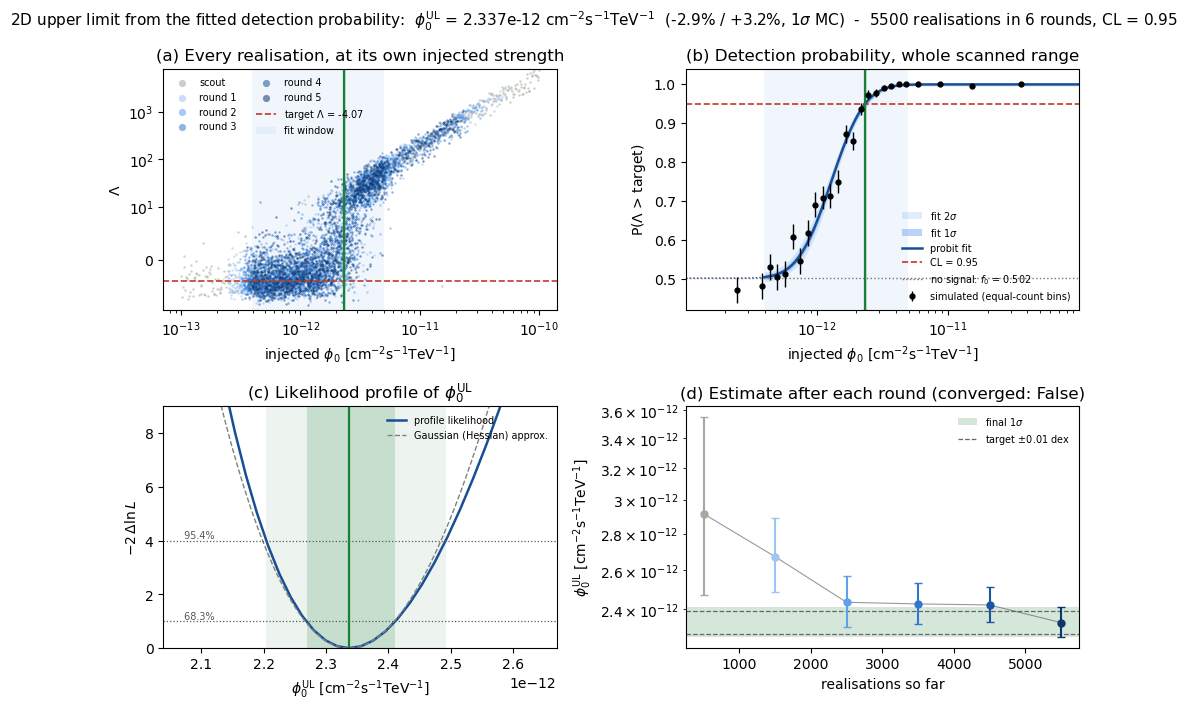

In [31]:
if not USE_ITERATIVE_ULS:
    lambda_f_m = np.array([np.percentile(l, 50) for l in lambda_f])

    # The fraction of lambdas simulated larger than the data or the BKG of lambda
    lambda_f_frac_bkg  = np.array([np.sum(l > lambda_bkg_m) / len(l) for l in lambda_f])
    lambda_f_frac_real = np.array([np.sum(l > lambda_real)  / len(l) for l in lambda_f])

    # Fitting a sigmoid to the fraction of lambdas
    x_bkg, y_bkg = np.log10(amplitudes), lambda_f_frac_bkg
    popt_bkg, pcov_bkg   = curve_fit(
        utils.sigmoid, x_bkg, y_bkg, p0=[max(y_bkg), np.median(x_bkg), 1, min(y_bkg)]
    )
    x_real, y_real = np.log10(amplitudes), lambda_f_frac_real
    popt_real, pcov_real = curve_fit(
        utils.sigmoid, x_real, y_real, p0=[max(y_real), np.median(x_real), 1, min(y_real)]
    )

    # We check manually where the threshold point is
    amplitude95_bkg  = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_bkg, cl=confidence_level)
    amplitude95_real = utils.find_amplitude_at_cl(np.log10(amplitudes), lambda_f_frac_real, cl=confidence_level)

    idx_f_bkg  = np.abs(amplitudes - amplitude95_bkg).argmin()
    idx_f_real = np.abs(amplitudes - amplitude95_real).argmin()

    plotting.plot_grid_crossing_curve(amplitudes, lambda_f_frac_bkg, lambda_f_frac_real,
                                      amplitude95_bkg, amplitude95_real, confidence_level, energy_edges)

elif cache.get("ul_method") == "fit":
    plotting.plot_ul_fit(cache, label="\\phi_0", unit="cm$^{-2}$s$^{-1}$TeV$^{-1}$", method_label="2D")
else:
    plotting.plot_ul_convergence(
        cache["hist_amp"], cache["hist_frac"], cache.get("hist_err"),
        x_ul=amp_ul, cl=confidence_level,
        x_ul_lo_1sigma=cache.get("x_ul_lo_1sigma"), x_ul_hi_1sigma=cache.get("x_ul_hi_1sigma"),
        label="\\phi_0", unit="cm$^{-2}$s$^{-1}$TeV$^{-1}$", method_label="2D",
        converged=cache.get("converged"), bracket_width_dex=cache.get("bracket_width_dex", float("nan")),
        n_monotonicity_violations=cache.get("n_monotonicity_violations", 0),
        at_bracket_edge=cache.get("at_bracket_edge", False), bracket_warning=cache.get("bracket_warning"),
    )

##### Summary of the 2D limit
The limit as photon flux, energy flux and SED point, all band integrals of the same power law
(§5.1), and the trials-factor sanity check: the global limit should sit at or above the largest
per-pixel sky-map UL in the 95% region (§7.7).

In [32]:
print(f"Analysis of {type_obs} data in energies {energy_edges[0]:.2f}-{energy_edges[1]:.2f}")
print(f"Significance of observations: {significance:+.2f} sigma "
      f"({'under' if significance < 0 else 'over'}-fluctuation -> limit referenced to "
      f"{'the BKG median' if significance < 0 else 'the observed'} Lambda)\n")

if not USE_ITERATIVE_ULS:
    fp_bkg  = simulate.flux_point_from_amplitude(amplitude95_bkg,  energy_edges, spectral_index, e_ref)
    fp_real = simulate.flux_point_from_amplitude(amplitude95_real, energy_edges, spectral_index, e_ref)

    col_sens = "33" if significance >= 0.0 else "32"
    col_ul   = "32" if significance >= 0.0 else "31"
    print(f"\033[{col_sens}mSensitivity (BKG median crossing)\033[0m")
    print("  " + str(fp_bkg).replace("\n", "\n  "))
    print(f"\033[{col_ul}mUpper limit (real data crossing)\033[0m")
    print("  " + str(fp_real).replace("\n", "\n  "))

    flux_point_2d = fp_bkg if significance < 0 else fp_real
    flux_bkg,  flux_diff_bkg  = fp_bkg.photon_flux,  fp_bkg.energy_flux
    flux_real, flux_diff_real = fp_real.photon_flux, fp_real.energy_flux

else:
    flux_point_2d = cache.get("flux_point") or simulate.flux_point_from_amplitude(
        amp_ul, energy_edges, spectral_index, e_ref)
    print("\033[32m2D FLUX UPPER LIMIT\033[0m")
    print("  " + str(flux_point_2d).replace("\n", "\n  "))
    if np.isfinite(cache.get("x_ul_lo_1sigma", np.nan)):
        # Every quantity above scales with phi0, so they all share its relative MC uncertainty.
        _rel = (cache["x_ul_lo_1sigma"] / amp_ul - 1, cache["x_ul_hi_1sigma"] / amp_ul - 1)
        print(f"  MC 1 sigma: {_rel[0]:+.1%} / {_rel[1]:+.1%} on each of the above "
              f"(phi0 in [{cache['x_ul_lo_1sigma']:.3e}, {cache['x_ul_hi_1sigma']:.3e}])")
    flux_real, flux_diff_real = flux_point_2d.photon_flux, flux_point_2d.energy_flux

final_f_ul = flux_point_2d.photon_flux

# --- CROSSCHECK: the global (Monte-Carlo) UL against the per-pixel sky-map UL --
# These are different statistics -- the MC limit is on the *maximum* of TS' over
# the whole 95% region and therefore includes the trials factor, whereas the
# ExcessMapEstimator UL is a per-pixel limit with no trials correction. The MC
# limit should therefore land at or above the sky-map maximum; a value well
# below it would mean the trials penalty has gone missing somewhere.
flux_ul_95_max = np.nanmax(flux_uls_95)
flux_ul_max    = np.nanmax(flux_uls)
_v = final_f_ul.value
print(f"\nUL vs sky-map 95% max: {_v:.3e} vs {flux_ul_95_max:.3e}  "
      f"({(_v - flux_ul_95_max) / flux_ul_95_max * 100:+.1f}%)")
print(f"UL vs sky-map max:     {_v:.3e} vs {flux_ul_max:.3e}  "
      f"({(_v - flux_ul_max) / flux_ul_max * 100:+.1f}%)")
if _v < flux_ul_95_max:
    print("  NOTE: the global limit is BELOW the per-pixel sky-map maximum. The global "
          "limit accounts for the trials factor over the 95% region, so it is normally "
          "the looser of the two -- worth checking the containment factor and that both "
          "assume the same spectral index.")

Analysis of stereo data in energies 0.60 TeV-20.00 TeV
Significance of observations: -0.23 sigma (under-fluctuation -> limit referenced to the BKG median Lambda)

2D FLUX UPPER LIMIT
  phi0        = 2.337e-12 cm-2 s-1 TeV-1 @ 1.00 TeV
  photon flux = 3.778e-12 cm-2 s-1        [0.60 TeV-20.00 TeV]
  energy flux = 1.313e-11 erg cm-2 s-1    [0.60 TeV-20.00 TeV]
  E2 dN/dE    = 3.744e-12 erg cm-2 s-1 @ 3.46 TeV
  MC 1 sigma: -2.9% / +3.2% on each of the above (phi0 in [2.269e-12, 2.411e-12])

UL vs sky-map 95% max: 3.778e-12 vs 4.545e-12  (-16.9%)
UL vs sky-map max:     3.778e-12 vs 1.039e-11  (-63.6%)
  NOTE: the global limit is BELOW the per-pixel sky-map maximum. The global limit accounts for the trials factor over the 95% region, so it is normally the looser of the two -- worth checking the containment factor and that both assume the same spectral index.


#### Showing the threshold simulated case (grid-scan only)

In [33]:
if not USE_ITERATIVE_ULS:
    pwl_sim = PowerLawSpectralModel(
        amplitude=amplitudes[idx_f_bkg if significance < 0 else idx_f_real] * u.Unit("TeV-1 s-1 cm-2"), index=2
    )
    flux_sim = pwl_sim.integral(*energy_edges)

    plotting.plot_grid_threshold_case(
        lambda_bkg, lambda_bins, lambda_f[idx_f_bkg if significance < 0 else idx_f_real],
        lambda_bins_ext, lambda_real, lambda_bkg_m, p_value, significance, flux_sim, energy_edges,
    )

#### Showing the ULs in front of the real distributions

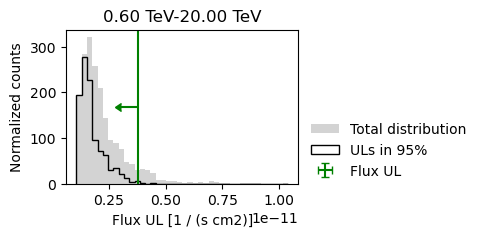

In [34]:
plotting.plot_uls_vs_real_distribution(
    flux_uls, flux_uls_95,
    flux_real=(flux_real.value if hasattr(flux_real, "value") else float(flux_real)),
    energy_edges=energy_edges, significance=significance,
    flux_bkg=(flux_bkg.value if not USE_ITERATIVE_ULS else None),
)

#### Showing UL distributions in the simulations (grid-scan only)

In [35]:
if compute_uls and not USE_ITERATIVE_ULS:
    flux_ul = flux_bkg if significance < 0 else flux_real
    plotting.plot_grid_ul_distributions(ulmax_bkg, flux_uls_95, ul_dist, mask_threshold_95,
                                        flux_ul.value, energy_edges)

In [36]:
if compute_uls and not USE_ITERATIVE_ULS:
    ts2_masked_flat = np.where(mask_threshold_95, ts2, np.nan).ravel()
    plotting.plot_grid_ts_distributions(lambda_bkg, ts2_masked_flat, ts2_dist, mask_threshold_95, energy_edges)

### 3D luminosity upper limit

The same construction as the 2D flux limit, but at fixed **isotropic-equivalent band luminosity
$L_0$**; for each realisation (§6.4):

1. draw a WCS bin from the **full, unmasked** GW sky probability (`prob_gw`),
2. draw a distance from that bin's distance CDF (`cdf_table`),
3. convert $(L_0, d)$ into an amplitude by integrating the power law over the band,
   $\phi_0 = L_0 / [4\pi d_L^2 (1+z)^{\Gamma-2}] / (E_0^2 \int x^{1-\Gamma}dx)$ (§5.2),
4. inject and `fake` a source with that amplitude at the bin centre.

The $L_0$ limit uses the same method as the 2D limit (`UL_METHOD`, `N_JOBS`, `ul_*`).

**What $L_0$ means.** The luminosity in the analysis band $[E_{\min}, E_{\max}]$, *not* a bolometric
luminosity, and without EBL absorption (§5.4; the emission-model limit below includes it).

**Options** (next cell):
* `luminosity_band_3d`: band in which $L_0$ is defined; `None` = the analysis band, directly
  comparable to the 2D limit,
* `apply_k_correction`: the $(1+z)^{\Gamma-2}$ factor, identically 1 at Γ = 2,
* `restrict_to_mask_3d`: `False` draws from the full map (the 3D method; looser than 2D by
  construction), `True` only inside the 95% region, which isolates the effect of the distance
  marginalisation,
* `lum_lo`, `lum_hi`: span of the fit's first batch / bisection bracket, checked before the limit
  is trusted.

In [37]:
# --- 3D (luminosity) config ---
n_sim_lum          = n_sim_flux   # simulations per L0 bisection step, and per closure test
precision_3d       = 0.02         # bisection only: bracket width to stop on, in dex
frac_tol_3d        = 0.005        # bisection only: widened automatically to 2x the binomial MC error
lum_lo, lum_hi     = 1e42, 1e50   # erg/s: bisection bracket, or span of the fit's first batch
                                  # (either way checked before the limit is trusted)
max_iter_3d        = 20           # bisection only

# Band in which L0 is defined. `None` -> the analysis band, which is what makes
# the 3D limit directly comparable with the 2D one. Point it at a fixed
# reference band (e.g. [0.1, 100] TeV) only if you need a literature-comparable
# number, and say so when quoting it.
luminosity_band_3d = None
apply_k_correction = True        # identically 1 at index 2; only matters otherwise

# Sky support of the 3D draw.
#   False -> sample the FULL GW map. This is the point of the 3D method: the
#            limit is marginalised over all the probability, including the part
#            outside the 95% contour where Lambda is heavily penalised. It makes
#            the 3D limit LOOSER than a 2D limit converted at the same distance,
#            by construction and not by mistake.
#   True  -> sample only inside mask_threshold_95, i.e. the same sky support the
#            2D method uses. Any remaining difference between the two limits is
#            then purely the distance marginalisation. Useful as a crosscheck;
#            rerun the bisection with it to isolate the two effects.
restrict_to_mask_3d = False

_band_3d = energy_edges if luminosity_band_3d is None else luminosity_band_3d
print(f"L0 will be defined in [{_band_3d[0]:.2f}, {_band_3d[-1]:.2f}] "
      f"with index {spectral_index}, K-correction {'on' if apply_k_correction else 'off'}")

L0 will be defined in [0.60 TeV, 20.00 TeV] with index 2.0, K-correction on


#### Crosscheck: the 3D sampler itself

Validates the **production sampler** `simulate.sample_sky_and_distance`, the function
`perform_n_simulations_3d` calls, not a re-implementation of it:

1. **Sky marginal**: $\chi^2$ of the sampled per-bin frequencies against the renormalised `prob_gw`,
   on bins with enough expected counts.
2. **Distance marginal**: KS test of the sampled distances against the analytic mixture
   $\sum_b w_b\, p(d\,|\,b)$; probability atoms at the edges of `r_grid` are reported separately.
3. **Support**: no draw at $d \le 0$, since $1/d^2$ would inject an infinite flux.

The sampled mean distance is also compared with the sky-marginalised posterior of Part 1, and
$\langle 1/d^2\rangle$ with $1/d_{\rm med}^2$, the reason a 3D limit differs from a 2D limit
converted at the median distance.

  Input OK [3d]: grid (44, 44),  mask 1038 px (53.6%),  GW prob in mask 95.0% of FoV total 98.9%,  containment 0.682
             distance grid 1000 pts [1, 10000] Mpc,  1924 valid bins carrying 100.0% of the sky probability

3D sampler crosschecks
  Sky marginal      chi2/dof = 855.5/849  p = 0.431  (OK)
  Distance marginal KS = 0.0053  (5% critical 0.0096, p = 0.622, interior N = 20000)
  Hottest bin (20, 20) conditional KS = 0.0775 (5% critical 0.1674, N = 66)
  Distances: median 1423 Mpc, mean 1424 Mpc, <1/d^2> = 5.433e-07 Mpc^-2
  Support: 0 non-positive draws, within r_grid = True
  VERDICT: PASS


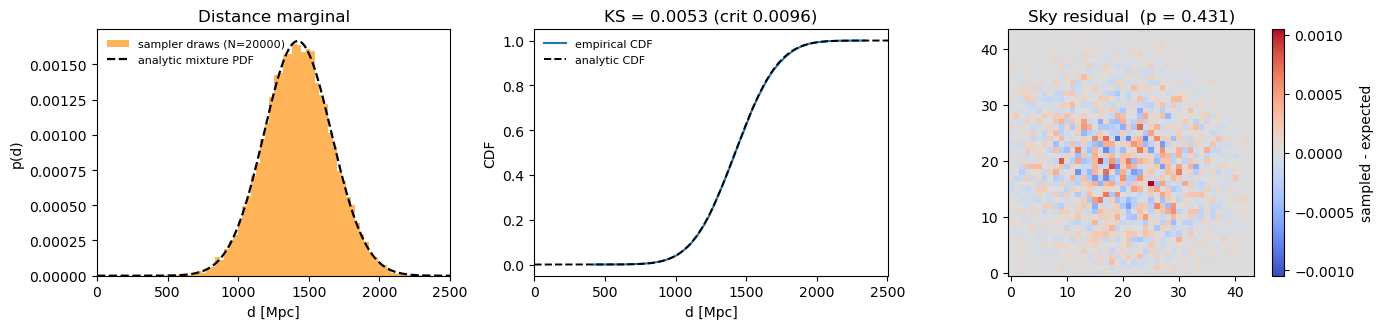


<d> sampler = 1424.0 Mpc   vs   analytic mixture 1422.1 Mpc   (difference 1.9, MC error 1.7)
  consistent

<1/d^2>   = 5.4332e-07 Mpc^-2
1/d_med^2 = 4.9377e-07 Mpc^-2   (ratio 1.100)
  -> the nearest realisations carry disproportionate weight; a limit quoted at the median distance is not the distance-marginalised limit.

GW probability reachable by the 3D draw (full map)      : 100.0%
GW probability inside the 95% mask (2D method support)  : 96.0%
Currently sampling: the full map


In [38]:
if RUN_CROSSCHECKS:
    check_3d = simulate.check_3d_sampling(
        path_pkl, n_sim=20000, seed=7,
        restrict_to_mask=restrict_to_mask_3d, make_plot=True)

    # Tie it back to the canonical full-sky marginal built in Part 1
    # (cdf_marg/pdf_marg/mean_agg): the sampler's mean distance must agree
    # with it to within its own MC error.
    _mc_err = np.sqrt(np.trapezoid((r_grid - mean_agg) ** 2 * pdf_marg, r_grid) / check_3d["n_sim"])
    _delta  = abs(check_3d["d_mean"] - mean_agg)
    print(f"\n<d> sampler = {check_3d['d_mean']:.1f} Mpc   vs   analytic mixture "
          f"{mean_agg:.1f} Mpc   (difference {_delta:.1f}, MC error {_mc_err:.1f})")
    print("  " + ("consistent" if _delta < 4 * _mc_err else
                  "INCONSISTENT -- the injector is not drawing from the posterior "
                  "the earlier cells validated"))

    # <1/d^2> is the quantity the luminosity limit actually depends on. It is NOT
    # 1/<d>^2: for this posterior the difference is the entire reason a 3D limit
    # differs from a 2D limit evaluated at the median distance.
    _inv_d2_naive = 1.0 / check_3d["d_median"] ** 2
    print(f"\n<1/d^2>   = {check_3d['inv_d2_mean_Mpc-2']:.4e} Mpc^-2")
    print(f"1/d_med^2 = {_inv_d2_naive:.4e} Mpc^-2   "
          f"(ratio {check_3d['inv_d2_mean_Mpc-2'] / _inv_d2_naive:.3f})")
    print("  -> the nearest realisations carry disproportionate weight; a limit quoted "
          "at the median distance is not the distance-marginalised limit.")
    # How much of the GW probability the 3D draw can actually reach, and how
    # that compares with the 2D method's support. If these differ a lot, the two
    # limits are not the same statistic -- see `restrict_to_mask_3d` above.
    _p_full = prob_gw_integrated[cdf_valid].sum() / prob_gw_integrated.sum()
    _p_mask = prob_gw_integrated[cdf_valid & mask_threshold_95].sum() / prob_gw_integrated.sum()
    print(f"\nGW probability reachable by the 3D draw (full map)      : {_p_full*100:.1f}%")
    print(f"GW probability inside the 95% mask (2D method support)  : {_p_mask*100:.1f}%")
    print(f"Currently sampling: {'the 95% mask' if restrict_to_mask_3d else 'the full map'}")

In [39]:
%%time
_stem_3d = gwpaths.run_stem(source_name, type_obs, e_min.value, e_max.value, bkg_type,
                            correlation_radius.value, binsz, use_dirac_delta=USE_DIRAC_DELTA)
_tag_3d = (f"band{u.Quantity(_band_3d[0]).to_value(u.TeV):g}-{u.Quantity(_band_3d[-1]).to_value(u.TeV):g}_idx{spectral_index}"
           f"_k{int(apply_k_correction)}{'_masked' if restrict_to_mask_3d else ''}")
_iter_cache_3d = os.path.join(str(gwpaths.TMP_DIR), (
    f"{_stem_3d}_fitul3d_{_tag_3d}_prec{ul_precision}_max{ul_max_sims}.pkl" if UL_METHOD == "fit" else
    f"{_stem_3d}_iterative3d_nsim{n_sim_lum}_prec{precision_3d}_fractol{frac_tol_3d}"
    f"{'_masked' if restrict_to_mask_3d else ''}.pkl"))
# every simulated round of the fit, reused on a rerun (see the 2D cell)
_fit_rounds_3d = os.path.join(str(gwpaths.TMP_DIR), (
    f"{_stem_3d}_fitul3d_rounds_{_tag_3d}_seed{seed_fit}_{seed_sampling}"
    f"_pkl{int(os.path.getmtime(path_pkl))}.pkl"))

if os.path.exists(_iter_cache_3d) and not OVERWRITE_RESULTS:
    print("Loading 3D iterative UL cache...")
    with open(_iter_cache_3d, "rb") as f:
        cache_3d = pickle.load(f)
else:
    if UL_METHOD == "fit":
        cache_3d = simulate.run_fit_ul_3d(
            path_pkl           = path_pkl,
            lambda_real        = lambda_real,
            lambda_bkg         = lambda_bkg,
            lambda_bkg_m       = lambda_bkg_m,
            significance       = significance,
            cl                 = confidence_level,
            lum_lo             = lum_lo,
            lum_hi             = lum_hi,
            n_scout            = ul_n_scout,
            n_refine           = ul_n_refine,
            precision          = ul_precision,
            max_sims           = ul_max_sims,
            cache_path         = _fit_rounds_3d,
            spectral_index     = spectral_index,
            e_ref              = e_ref,
            seed               = seed_fit,
            sampling_seed      = seed_sampling,
            luminosity_band    = luminosity_band_3d,
            apply_k_correction = apply_k_correction,
            restrict_to_mask   = restrict_to_mask_3d,
            n_jobs             = N_JOBS,
        )
    else:
        _n_sim_3d = (simulate.geometric_n_sim_schedule(max(50, n_sim_lum // 8), n_sim_lum)
                     if USE_DYNAMIC_N_SIM else n_sim_lum)
        cache_3d = simulate.run_iterative_ul_3d(
            path_pkl           = path_pkl,
            lambda_real        = lambda_real,
            lambda_bkg         = lambda_bkg,
            lambda_bkg_m       = lambda_bkg_m,
            significance       = significance,
            p_value            = p_value,
            cl                 = confidence_level,
            n_sim              = _n_sim_3d,
            precision          = precision_3d,
            frac_tol           = frac_tol_3d,
            lum_lo             = lum_lo,
            lum_hi             = lum_hi,
            max_iter           = max_iter_3d,
            spectral_index     = spectral_index,
            e_ref              = e_ref,
            seed               = seed_fake,
            sampling_seed      = seed_sampling,
            luminosity_band    = luminosity_band_3d,
            apply_k_correction = apply_k_correction,
            restrict_to_mask   = restrict_to_mask_3d,
            check_bracket      = True,
            n_jobs             = N_JOBS,
        )
    with open(_iter_cache_3d, "wb") as f:
        pickle.dump(cache_3d, f)
    print(f"Saved 3D iterative UL cache -> {_iter_cache_3d}")

result_3d = cache_3d
lum_ul    = cache_3d["lum_ul"]


Loading 3D iterative UL cache...
CPU times: user 782 μs, sys: 4.29 ms, total: 5.08 ms
Wall time: 22.5 ms


#### Verifying the 3D limit

The same diagnostics as for the 2D limit. For the curve fit (`plotting.plot_ul_fit`): every
realisation's $\Lambda$ against its own $L_0$, the fitted detection probability with its band over
the whole bracket and around the limit, the likelihood profile that the limit's uncertainty comes
from, the estimate after each round, and the pulls of the fit. For the bisection: the convergence
trace and the $\Lambda$ distributions of every $L_0$ tested; if its crossing curve is not monotonic
in $L_0$ beyond the error bars, the bisection's assumption is violated and the limit is not
trustworthy no matter how tight the bracket looks.


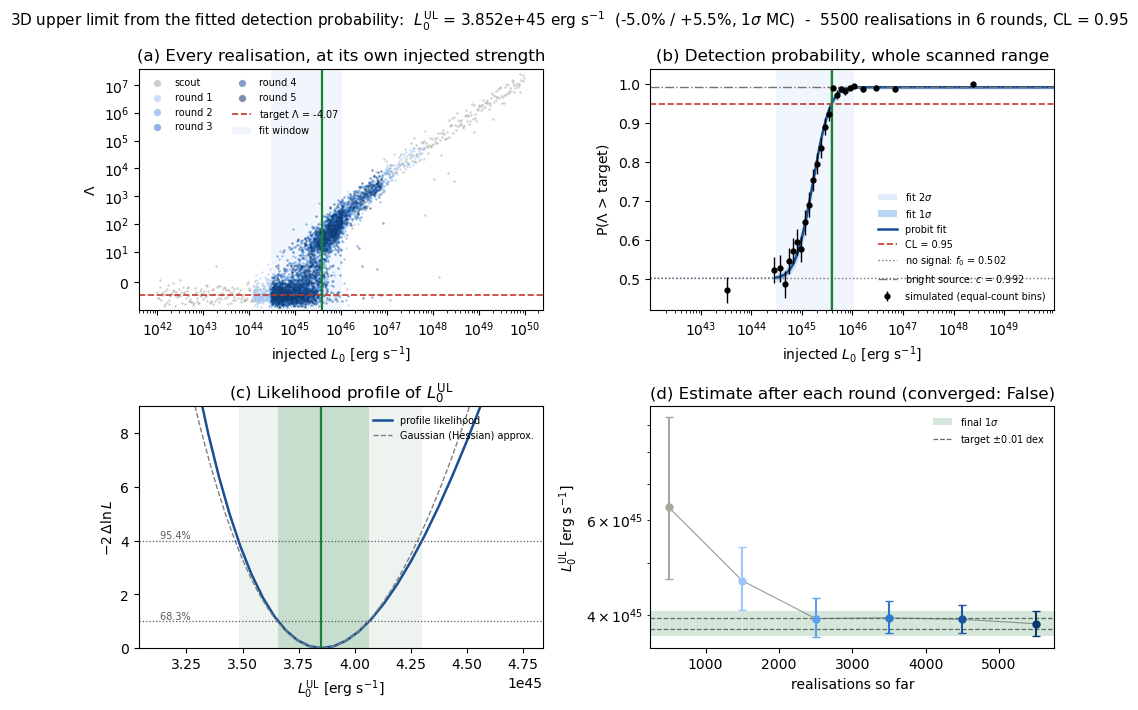

In [40]:
if cache_3d.get("ul_method") == "fit":
    plotting.plot_ul_fit(cache_3d, label="L_0", unit="erg s$^{-1}$", method_label="3D")
else:
    plotting.plot_ul_convergence(
        cache_3d["hist_lum"], cache_3d["hist_frac"], cache_3d.get("hist_err"),
        x_ul=lum_ul, cl=confidence_level,
        x_ul_lo_1sigma=cache_3d.get("x_ul_lo_1sigma"), x_ul_hi_1sigma=cache_3d.get("x_ul_hi_1sigma"),
        label="L_0", unit="erg/s", method_label="3D",
        converged=cache_3d.get("converged"), bracket_width_dex=cache_3d.get("bracket_width_dex", float("nan")),
        n_monotonicity_violations=cache_3d.get("n_monotonicity_violations", 0),
        at_bracket_edge=cache_3d.get("at_bracket_edge", False), bracket_warning=cache_3d.get("bracket_warning"),
    )

In [41]:
# CROSSCHECK: (a) the injected-signal Lambda distribution must separate from BKG
# monotonically as L0 grows, and (b) the tested L0 values must actually straddle
# the target -- if they all sit on one side of it the bisection never bracketed
# the crossing and the returned "limit" is a bracket edge.
# (For the curve fit, panel (a) of the figure above already shows every realisation.)
target_lambda = cache_3d["target"]
if "lambda_cache" in cache_3d:
    plotting.plot_lambda_distributions_by_x(
        lambda_bkg, lambda_real, lambda_bkg_m,
        {float(k): v for k, v in cache_3d["lambda_cache"].items()},
        target_lambda=target_lambda, cl=confidence_level,
        x_label="L_0", x_unit="erg s$^{-1}$",
    )

#### Crosscheck: closure test at the quoted limit

$L_0^{\rm UL}$ is read off a fitted curve (or interpolated between bisection steps), so it was not
itself simulated. A fresh set of realisations **at exactly $L_0^{\rm UL}$**, with independent seeds,
must give a fraction of $\Lambda$ above the target equal to the CL (§7.6). The pull
(`simulate.closure_pull`) combines the binomial error of that sample with the limit's own MC
uncertainty mapped through the fitted curve; $|{\rm pull}| < 3$ passes. A failure means the limit is
wrong however cleanly the search converged.

  Input OK [3d]: grid (44, 44),  mask 1038 px (53.6%),  GW prob in mask 95.0% of FoV total 98.9%,  containment 0.682
             distance grid 1000 pts [1, 10000] Mpc,  1924 valid bins carrying 100.0% of the sky probability
Producing 1000 3D simulations for L0 = 3.852e+45 erg/s in [0.60 TeV, 20.00 TeV] (index 2.0)...
  Sampled d: median 1417 Mpc, 90% CI [1007, 1826] Mpc
  Implied phi0: median 2.855e-12, 90% CI [1.719e-12, 5.651e-12] cm-2 s-1 TeV-1
  L -> phi0 -> L round trip on 64 draws: max rel. error 2.22e-16


Simulating (10 workers):   0%|          | 0/1000 [00:00<?, ?sim/s]


Writing file --> /fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/tmp/closure3d_3.852104e+45.npz  (0.1 MB)

CLOSURE TEST at L0 = 3.8521e+45 erg/s  (N = 1000, independent seeds)
  fraction > target : 0.9620 +- 0.0060 (binomial) +- 0.0064 (MC uncertainty of the limit)
  confidence level  : 0.9500
  pull              : +1.36 sigma   -> PASS


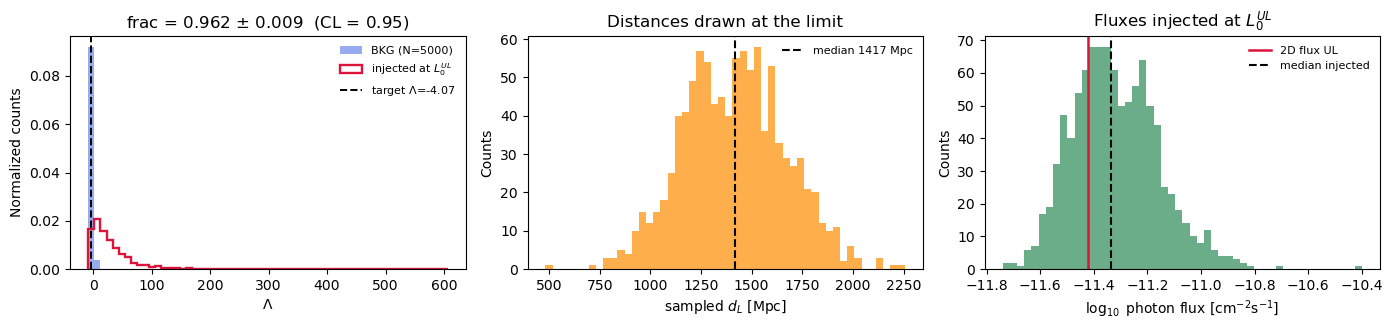

In [42]:
RUN_CLOSURE_TEST = True   # costs one extra block of n_sim_lum simulations

if RUN_CLOSURE_TEST:
    _closure_file = os.path.join(str(gwpaths.TMP_DIR), f"closure3d_{lum_ul:.6e}.npz")
    simulate.perform_n_simulations_3d(
        n_sim              = n_sim_lum,
        luminosity         = lum_ul,
        file_input         = path_pkl,
        file_output        = _closure_file,
        compute_uls        = 0,
        spectral_index     = spectral_index,
        e_ref              = e_ref,
        seed               = 900_000,          # independent background realisations
        sampling_seed      = 987_654,          # independent sky/distance draws
        luminosity_band    = luminosity_band_3d,
        apply_k_correction = apply_k_correction,
        restrict_to_mask   = restrict_to_mask_3d,
        store_ts_maps      = False,
        store_stats        = False,
        n_jobs             = N_JOBS,
    )
    _cl_data   = np.load(_closure_file, allow_pickle=True)
    lambda_clo = _cl_data["lambda_data"]
    d_clo, amp_clo = _cl_data["d_sim"], _cl_data["amp_sim"]

    _clo = simulate.closure_pull(cache_3d, lambda_clo)
    _frac_clo, _err_clo, _pull = _clo["frac"], _clo["err_tot"], _clo["pull"]

    print(f"\n{'='*70}")
    print(f"CLOSURE TEST at L0 = {lum_ul:.4e} erg/s  (N = {len(lambda_clo)}, independent seeds)")
    print(f"  fraction > target : {_frac_clo:.4f} +- {_clo['err']:.4f} (binomial) "
          f"+- {_clo['err_ul']:.4f} (MC uncertainty of the limit)")
    print(f"  confidence level  : {confidence_level:.4f}")
    print(f"  pull              : {_pull:+.2f} sigma   "
          f"{'-> PASS' if abs(_pull) < 3 else '-> FAIL, the quoted limit is biased'}")
    print(f"{'='*70}")

    _photon_flux_clo = np.array([
        simulate.pwl_photon_flux(a, energy_edges, spectral_index, e_ref).value for a in amp_clo])
    plotting.plot_closure_test(
        lambda_bkg, lambda_clo, target_lambda, _frac_clo, _err_clo, confidence_level,
        d_clo, _photon_flux_clo, flux_point_2d.photon_flux.value, x_label="L_0",
    )

### 3D luminosity upper limit with the emission model

The same limit as above (`UL_METHOD`), but each realisation injects the GRB afterglow model instead of
the Γ = 2 power law (`simulate.EmissionModelInjection`, §11; guidelines Steps 4.3, 6 and 7 [10]):

1. a sky position, a distance and a viewing angle, all drawn by `simulate.sample_injections_3d`
   (table below). The source is injected at the centre of the WCS bin its position falls in. The
   test statistic is unchanged: $\Lambda$ still weights by the **skymap** $p_{\rm GW}$, which is what
   the real data were analysed with. Only the simulated source population depends on the choice,
2. the default is the **joint PE draw** (`SKY_DISTANCE_MODE = THETA_MODE = "pe"`): one PE posterior
   sample per realisation, its RA, Dec, $d_L$ and $\theta_v$ taken together. That is an exact draw
   from $p(\Omega, d, \theta_v \mid \mathrm{data})$: no factorisation and no density estimate, and the
   distance–angle degeneracy and its sky dependence are kept sample by sample. Samples outside the
   analysis geometry (or the 95% mask with `restrict_to_mask_3d`) are dropped, which conditions the
   joint on the sky support, as the skymap route does when it renormalises `prob_gw` over the map.
   The skymap route instead pairs skymap distances with the PE's $p(\theta_v \mid d)$; for S240615dg
   the skymap puts the source nearer than the final PE, so that route draws $\theta_v$ about 8°
   further off-axis (crosscheck (4) below; [8], §8),
3. the fixed phenomenological jet at $\theta_v$, built with the recipe of [5, 6] and population-median
   inputs ([`setup_model_phenomenological_fixed.ipynb`](setup_model_phenomenological_fixed.ipynb)),
   projected to $(d, z)$ with EBL absorption at $z$ [7],
4. averaged over each run's own GTIs ($t$ = time since the merger) and folded through that run's own
   exposure, PSF and energy dispersion, then summed. The analysis is time-integrated, so this is
   exact with no temporal template; a fading source weights the early runs more,
5. normalised to the trial luminosity $L_k$.

| `SKY_DISTANCE_MODE` | `THETA_MODE` | $\theta_{v,i}$ | use |
|---|---|---|---|
| `"pe"` | `"pe"` | the same PE sample's angle | **default**: the event-specific limit, exact joint posterior |
| `"pe"` | `"gw"` | $p(\theta_v \mid d_i)$ from the PE KDE | cross-check of the KDE; loses the sky dependence |
| `"pe"` or `"skymap"` | `"fixed"` | `THETA_FIXED_DEG` | the jet at a given angle, a curve against $\theta_v$ |
| `"pe"` or `"skymap"` | `"isotropic"`, `"schutz"`, `"two_bin"` | the prior or dummy distribution, independent of $d_i$ | brackets and placeholders |
| `"pe"` or `"skymap"` | `"selection"` | detected population with horizon `THETA_HORIZON_MPC`, given $d_i$ | population-level, no PE angle |
| `"skymap"` | `"gw"` | $p(\theta_v \mid d_i)$ at the skymap distance | the previous notebook; alerts without PE use `"schutz"` or `"selection"` with it |

Without released PE only `"skymap"` works, and `THETA_MODE = "pe"` is rejected.

What $L_k$ means is set by `MODEL_NORMALISATION`:

- **`"gti_mean"`** (default, Step 6): the isotropic-equivalent luminosity in the analysis band, rest
  frame, averaged over the GTIs, the same for every realisation. The model's absolute brightness
  cancels; its shape reaches the limit (photon index 2.2, EBL at each $z$, the rest-frame band, and,
  through the run weights, the light curve). The direct counterpart of the power-law $L_0$.
- **`"anchor"`**: the jet's own normalisation, its on-axis $L_\mathrm{TeV}$ (0.3–1 TeV) at
  $t' = 11$ h. Every realisation is the same jet scaled by one factor, so its faintness at
  $\theta_v$ and at the observation time enter the limit too (at 50° the benchmark jet is $10^{-5}$
  of its on-axis brightness at 11 h). The limit then says how bright the benchmark jet would have to
  be to be excluded, set by the far-off-axis tail of $p(\theta_v)$.

`lum_lo_model`, `lum_hi_model` span a wider bracket than the power law. Each realisation computes one
`npred` per run, so this section is several times slower than the power-law 3D limit. EBL needs
`$GAMMAPY_DATA`.

In [43]:
from gwuls import grb_model, angle_distribution

# The angle spec of each THETA_MODE (simulate.resolve_theta_distribution)
_theta_specs = {
    "pe": "pe", "gw": str(theta_dist_path), "fixed": f"fixed:{THETA_FIXED_DEG:g}",
    "isotropic": "isotropic", "schutz": "schutz",
    "two_bin": f"two_bin:{THETA_TWO_BIN[0]:g}:{THETA_TWO_BIN[1]:g}",
    "selection": f"selection:{THETA_HORIZON_MPC:g}",
}
if THETA_MODE not in _theta_specs:
    raise ValueError(f"THETA_MODE {THETA_MODE!r} is not one of {list(_theta_specs)}")
theta_spec_3d = _theta_specs[THETA_MODE]

emission_model_3d = simulate.EmissionModelInjection(
    model_dir          = str(model_dir_3d),
    theta_distribution = theta_spec_3d,
    sky_distance       = SKY_DISTANCE_MODE,
    pe_source          = str(PE_SOURCE) if SKY_DISTANCE_MODE == "pe" else None,
    normalisation      = MODEL_NORMALISATION,
    ebl_reference      = EBL_REFERENCE,
)
# Every cache name of the model limit carries the choice, and the date of the files it reads
injection_tag_3d = (f"sky{SKY_DISTANCE_MODE}_theta"
                    + (THETA_MODE if THETA_MODE in ("pe", "gw") else theta_spec_3d.replace(":", "-")))
_pe_file = (str(PE_SOURCE) if str(PE_SOURCE).endswith(".h5") else gwpaths.gw_pe_path(str(PE_SOURCE)))
_injection_inputs = (([_pe_file] if SKY_DISTANCE_MODE == "pe" else [])
                     + ([theta_dist_path] if THETA_MODE == "gw" else []))
# Wider than the power-law bracket: EBL removes most of the flux above ~1 TeV at these
# distances, and "anchor" has to reach the far-off-axis draws.
lum_lo_model, lum_hi_model = 1e42, 1e58

if RUN_MODEL_3D:
    if emission_model_3d.apply_ebl and not os.environ.get("GAMMAPY_DATA"):
        raise RuntimeError("EBL absorption needs $GAMMAPY_DATA/ebl/ -- set GAMMAPY_DATA "
                           "(or pass apply_ebl=False to EmissionModelInjection).")
    with open(path_pkl, "rb") as f:
        _pkl = pickle.load(f)
    model_set_3d  = grb_model.GRBModelSet.load(model_dir_3d)
    _missing = [str(p) for p in _injection_inputs if not os.path.exists(p)]
    if _missing:
        raise FileNotFoundError(f"{injection_tag_3d} reads {_missing}: run setup_angle_distribution.ipynb "
                                "(PE file and p(theta | d)), or pick other SKY_DISTANCE_MODE / THETA_MODE.")
    injection_stamp_3d = max([int(os.path.getmtime(p)) for p in _injection_inputs], default=0)
    # the angle distribution, for the plots and checks (none for "pe": the angle comes with the sample)
    theta_dist_3d = None if THETA_MODE == "pe" else simulate.resolve_theta_distribution(theta_spec_3d)
    print(emission_model_3d.describe(energy_edges))
    print(f"Model: {len(model_set_3d.models)} angles, {model_set_3d.angles_deg[0]:g}-"
          f"{model_set_3d.angles_deg[-1]:g} deg, from {model_dir_3d}")
    print(f"Sky and distance: {SKY_DISTANCE_MODE!r}" + (f" ({_pe_file})" if SKY_DISTANCE_MODE == "pe" else ""))
    print(f"Viewing angle: THETA_MODE {THETA_MODE!r}, spec {theta_spec_3d!r}"
          + (f", kind {theta_dist_3d.kind!r}" if theta_dist_3d is not None else ", the PE sample's own"))
    print(f"Runs: {len(_pkl['datasets_runs'])}, GTIs "
          + ", ".join(f"{g[0, 0] / 3600:.2f}-{g[-1, 1] / 3600:.2f} h" for g in _pkl["run_gti_s"])
          + " after the merger")

L_k = the mean isotropic-equivalent luminosity over the GTIs, rest-frame 0.6-20 TeV
Model: 91 angles, 0-90 deg, from /fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/models/grb_afterglow_phenomenological/benchmark
Sky and distance: 'pe' (/fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/gw_pe/standardized/S240615dg.h5)
Viewing angle: THETA_MODE 'pe', spec 'pe', the PE sample's own
Runs: 5, GTIs 15.35-15.67 h, 15.69-16.01 h, 16.03-16.35 h, 16.37-16.69 h, 16.71-17.03 h after the merger


#### Crosschecks before the bisection

1. **Run by run = stacked, for a constant source.** A power law injected through each run and summed
   must give the stacked dataset's own prediction. The two differ only because the stacked PSF and
   energy dispersion are exposure-weighted averages over the runs, which is expected at the per-cent
   level at most.
2. **Step 6 closure.** For every draw, the rest-frame band luminosity rebuilt from the injected
   spectra (EBL divided out), averaged over the GTIs, must be exactly $L_k$ (`"gti_mean"` only).
3. **What gets injected,** from the production sampler with the production seed. The drawn viewing angles, where the GTIs fall on the model's light curve,
   how much the light curve changes between runs, and the EBL transmission over the drawn redshifts.
4. **The draws against the posterior.** The production draw is compared with the PE samples inside
   the same sky support (computed independently of the sampler): distance for
   `SKY_DISTANCE_MODE = "pe"`, angle and the distance–angle correlation for `THETA_MODE = "pe"`. The
   skymap route with the alert's $p(\theta_v \mid d)$ (the previous notebook) is shown next to it, so
   the shift between the two is measured for this alert and this geometry.


(1) constant source: 253.974 expected counts stacked, 252.923 run by run (-0.41%)
(2) Step 6 closure over 2000 draws: GTI-mean rest-frame luminosity per unit L_k = 1.00003 - 1.00003 (should be 1)


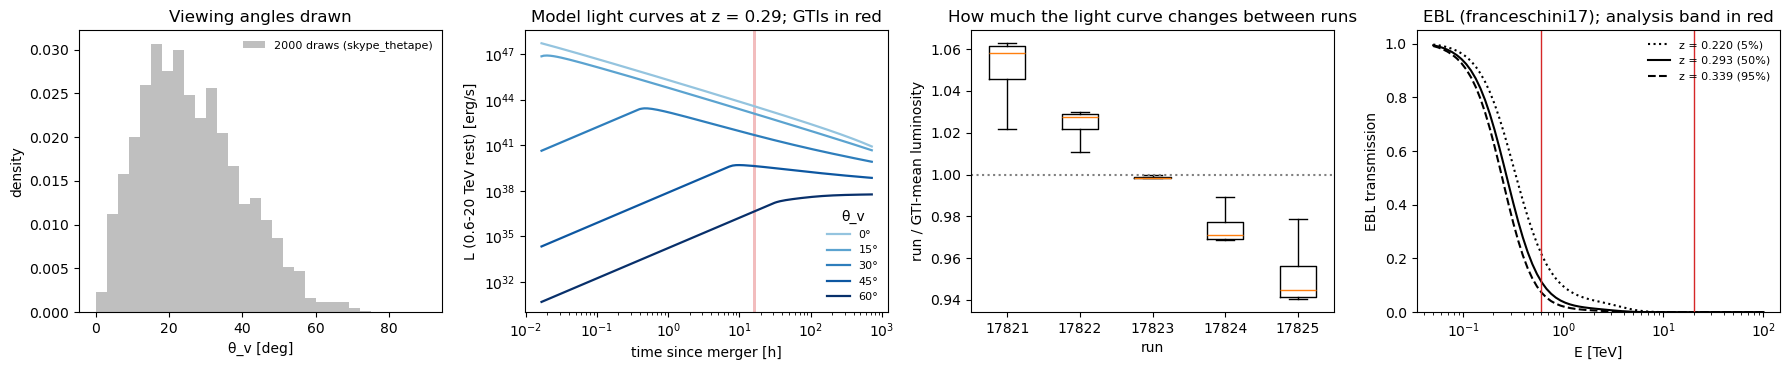

In [44]:
if RUN_MODEL_3D and RUN_CROSSCHECKS:
    # (1) run by run vs stacked, constant power law at the centre of the geometry
    _pl = PowerLawSpectralModel(index=2.2, amplitude="1e-11 cm-2 s-1 TeV-1", reference="1 TeV")
    _src = lambda: Models([SkyModel(spatial_model=PointSpatialModel.from_position(coord_center),
                                    spectral_model=_pl, name="check")])
    _ds = copy.deepcopy(_pkl["dataset"]); _ds.models = _src()
    _n_stacked = _ds.npred_signal().data
    _n_runs = 0.0
    for _run in _pkl["datasets_runs"]:
        _run.models = _src()
        _n_runs = _n_runs + _run.npred_signal().data * _run.mask_safe.data
        _run.models = None
    print(f"(1) constant source: {_n_stacked.sum():.3f} expected counts stacked, {_n_runs.sum():.3f} "
          f"run by run ({_n_runs.sum() / _n_stacked.sum() - 1:+.2%})")

    # (2)-(3) a preview draw: same sampler and theta stream as the production run
    _n_prev = 2000
    _draw = simulate.sample_injections_3d(
        emission_model_3d, prob_gw, cdf_valid, cdf_table, r_grid, _pkl["dataset"].geoms["geom"],
        bin_c_ra, bin_c_dec, _n_prev, seed_sampling,
        sky_mask=mask_threshold_95 if restrict_to_mask_3d else None)
    _th = _draw["theta_sim"]
    _z = simulate.redshift_from_luminosity_distance(_draw["d_sim"] * u.Mpc)
    _e_obs = np.geomspace(0.05, 100, 71)
    _spec, _info = simulate.emission_model_run_spectra(
        model_set_3d, _th, _draw["d_sim"], _z, _pkl["run_gti_s"], _e_obs, emission_model_3d, energy_edges)

    _dur = np.array([np.diff(g, axis=1).sum() for g in _pkl["run_gti_s"]])
    _lo, _hi = _info["band_rest_TeV"]
    _lum_back = np.empty(_n_prev)
    for _i in range(_n_prev):
        _e = np.geomspace(_lo / (1 + _z[_i]), _hi / (1 + _z[_i]), 200)   # observer energies of the rest band
        _intrinsic = np.maximum(_spec[_i] / np.maximum(_info["ebl"][_i], 1e-300), 1e-300)
        _F = np.array([np.exp(np.interp(np.log(_e), np.log(_e_obs), np.log(_r))) for _r in _intrinsic])
        _lum_back[_i] = (_dur @ np.trapezoid(_e * _F, _e, axis=1)) / _dur.sum() \
            * 4 * np.pi * (_draw["d_sim"][_i] * u.Mpc.to(u.cm)) ** 2 * u.TeV.to(u.erg)
    if emission_model_3d.normalisation == "gti_mean":
        print(f"(2) Step 6 closure over {_n_prev} draws: GTI-mean rest-frame luminosity per unit L_k = "
              f"{_lum_back.min():.5f} - {_lum_back.max():.5f} (should be 1)")
    else:
        print(f"(2) anchor: every draw is the jet x L_k / {_info['anchor_luminosity']:.3e} erg/s; its "
              f"GTI-mean luminosity per unit L_k spans {np.percentile(_lum_back, [5, 50, 95])}")

    fig, ax = plt.subplots(1, 4, figsize=(18, 3.8))
    ax[0].hist(_th, np.arange(0, 91, 3), density=True, color="0.75", label=f"{_n_prev} draws ({injection_tag_3d})")
    if theta_dist_3d is not None and theta_dist_3d.kind != "fixed":
        _tg, _pg = theta_dist_3d.pdf_grid()
        ax[0].plot(_tg, _pg, color="k", lw=1.5, label="marginal p(θ_v)")
    ax[0].set(xlabel="θ_v [deg]", ylabel="density", title="Viewing angles drawn")
    ax[0].legend(frameon=False, fontsize=8)

    _t = np.geomspace(60, 30 * 86400, 300)                     # observer time since merger
    _zm = np.median(_z)
    _band_e = np.geomspace(_lo * 1e3, _hi * 1e3, 32)
    for _theta, _c in zip([0, 15, 30, 45, 60], plt.cm.Blues(np.linspace(0.4, 1, 5))):
        _m = model_set_3d.get_model(float(_theta), method="interp", align_peaks=False)
        _L = np.trapezoid(_m.at(_band_e, _t / (1 + _zm)) * _band_e[:, None] ** 2, np.log(_band_e), axis=0) * u.GeV.to(u.erg)
        ax[1].loglog(_t / 3600, _L, color=_c, lw=1.6, label=f"{_theta}°")
    for _g in _pkl["run_gti_s"]:
        for _a, _b in _g:
            ax[1].axvspan(_a / 3600, _b / 3600, color="tab:red", alpha=0.3, lw=0)
    ax[1].set_ylim(1e30, None)
    ax[1].set(xlabel="time since merger [h]", ylabel=f"L ({_lo:g}-{_hi:g} TeV rest) [erg/s]",
              title=f"Model light curves at z = {_zm:.2f}; GTIs in red")
    ax[1].legend(frameon=False, fontsize=8, title="θ_v")

    ax[2].boxplot([_info["run_weight"][:, j] for j in range(_info["run_weight"].shape[1])], showfliers=False)
    ax[2].set_xticks(np.arange(1, len(obs_ids) + 1), [str(i) for i in obs_ids])
    ax[2].axhline(1, color="0.5", ls=":")
    ax[2].set(xlabel="run", ylabel="run / GTI-mean luminosity",
              title="How much the light curve changes between runs")

    for _q, _ls in zip([5, 50, 95], [":", "-", "--"]):
        _k = np.argsort(_z)[int(_q / 100 * (_n_prev - 1))]
        ax[3].semilogx(_e_obs, _info["ebl"][_k], color="k", ls=_ls, label=f"z = {_z[_k]:.3f} ({_q}%)")
    for _e in energy_edges:
        ax[3].axvline(u.Quantity(_e).to_value(u.TeV), color="tab:red", lw=1)
    ax[3].set(xlabel="E [TeV]", ylabel="EBL transmission", ylim=(0, 1.05),
              title=f"EBL ({EBL_REFERENCE}); analysis band in red")
    ax[3].legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

PE samples inside the sky support: 19616 of 20000 (98.1%)
PE sample -> injected bin centre: max 0.0565 deg (half a bin diagonal: 0.0566 deg)

                                            d_L 5/50/95 [Mpc]   theta_v 5/50/95 [deg] corr(d,cos) P(<20 deg)   KS d KS theta   (KS against the PE samples)
PE samples (reference)                       [1125 1566 1850]        [ 6.5 24.4 51. ]       0.823      0.373  0.000    0.000
production (skype_thetape)                   [1121 1564 1850]        [ 6.4 24.5 51.1]       0.824      0.374  0.007    0.005
skymap d -> p(θ|d) (previous)                [1028 1423 1823]        [ 9.1 32.5 56.1]       0.840      0.226  0.257    0.207

Distance drawn vs PE: PASS (KS limit 0.027)
Angle drawn vs PE:    PASS; corr(d, cos θ_v) 0.824 vs PE 0.823
Median theta_v, production - skymap route: -8.1 deg


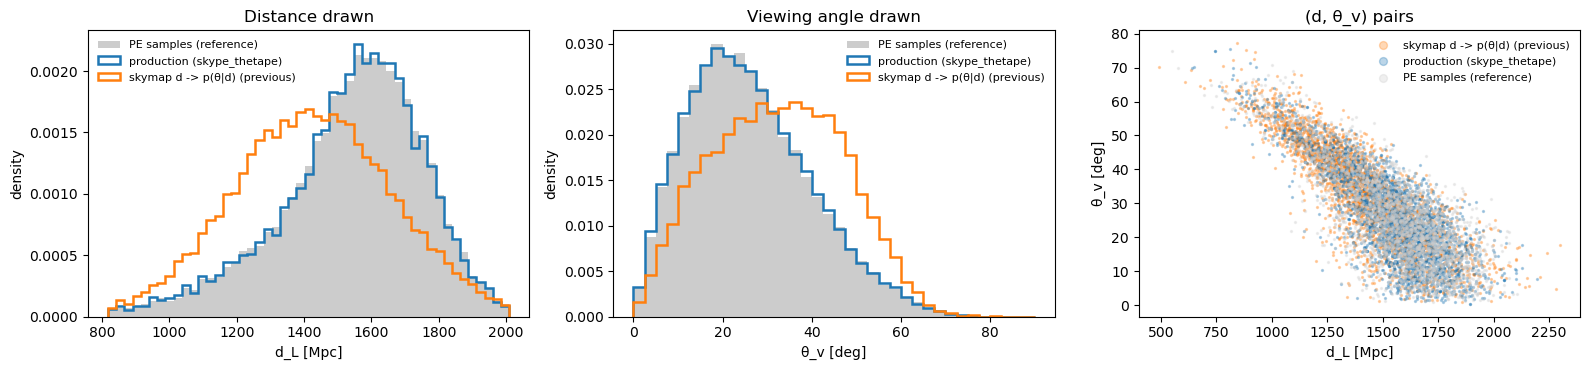

In [45]:
if RUN_MODEL_3D and RUN_CROSSCHECKS:
    # (4) the production draw against the PE samples, and against the skymap route of the previous notebook
    from scipy.stats import ks_2samp
    _n_chk   = 20000
    _sup     = mask_threshold_95 if restrict_to_mask_3d else None
    _geom_pk = _pkl["dataset"].geoms["geom"]
    _draw_args = (prob_gw, cdf_valid, cdf_table, r_grid, _geom_pk, bin_c_ra, bin_c_dec, _n_chk, 7)
    _prod = simulate.sample_injections_3d(emission_model_3d, *_draw_args, sky_mask=_sup)
    _rows = [(f"production ({injection_tag_3d})", _prod["d_sim"], _prod["theta_sim"])]

    # reference: the PE samples inside the same sky support, found here independently of the sampler
    _d_pe = _t_pe = None
    if os.path.exists(_pe_file):
        _s = simulate.pe_injection_samples(_pe_file)
        _ixs, _iys = (np.asarray(i, int) for i in _geom_pk.to_image().coord_to_idx(
            SkyCoord(ra=_s["ra_deg"] * u.deg, dec=_s["dec_deg"] * u.deg, frame="icrs")))
        _in = (_ixs >= 0) & (_iys >= 0)
        if _sup is not None:
            _in[_in] = _sup[_iys[_in], _ixs[_in]]
        _d_pe, _t_pe = _s["distance_Mpc"][_in], _s["theta_deg"][_in]
        _rows.insert(0, ("PE samples (reference)", _d_pe, _t_pe))
        print(f"PE samples inside the sky support: {_in.sum()} of {_in.size} ({_in.mean():.1%})")
    else:
        print(f"No standardized PE file {_pe_file}: PE reference skipped")
    # the skymap route with the alert's p(theta | d): what the previous notebook injected
    _sky = None
    if os.path.exists(theta_dist_path):
        _sky = simulate.sample_injections_3d(
            simulate.EmissionModelInjection(str(model_dir_3d), str(theta_dist_path)), *_draw_args, sky_mask=_sup)
        _rows.append(("skymap d -> p(θ|d) (previous)", _sky["d_sim"], _sky["theta_sim"]))
    if SKY_DISTANCE_MODE == "pe":
        _sep = SkyCoord(ra=_prod["ra_pe"] * u.deg, dec=_prod["dec_pe"] * u.deg).separation(
            SkyCoord(ra=_prod["ra"] * u.deg, dec=_prod["dec"] * u.deg)).deg
        print(f"PE sample -> injected bin centre: max {_sep.max():.4f} deg "
              f"(half a bin diagonal: {binsz * np.sqrt(2) / 2:.4f} deg)")

    _corr = lambda d, t: np.corrcoef(d, np.cos(np.radians(t)))[0, 1] if np.std(t) > 0 else np.nan
    _ks = lambda x, ref: ks_2samp(x, ref).statistic if ref is not None else np.nan
    print(f"\n{'':40s} {'d_L 5/50/95 [Mpc]':>20s} {'theta_v 5/50/95 [deg]':>23s} "
          f"{'corr(d,cos)':>11s} {'P(<20 deg)':>10s} {'KS d':>6s} {'KS theta':>8s}   (KS against the PE samples)")
    for _lab, _d, _t in _rows:
        print(f"{_lab:40s} {str(np.round(np.percentile(_d, [5, 50, 95])).astype(int)):>20s} "
              f"{str(np.round(np.percentile(_t, [5, 50, 95]), 1)):>23s} {_corr(_d, _t):11.3f} "
              f"{np.mean(_t < 20):10.3f} {_ks(_d, _d_pe):6.3f} {_ks(_t, _t_pe):8.3f}")
    if _d_pe is not None:
        _ks_crit = 2 * 1.36 * np.sqrt(1 / _n_chk + 1 / _d_pe.size)   # twice the 5% critical value
        if SKY_DISTANCE_MODE == "pe":
            print(f"\nDistance drawn vs PE: {'PASS' if _ks(_prod['d_sim'], _d_pe) < _ks_crit else 'MISMATCH'} "
                  f"(KS limit {_ks_crit:.3f})")
        if THETA_MODE == "pe":
            print(f"Angle drawn vs PE:    {'PASS' if _ks(_prod['theta_sim'], _t_pe) < _ks_crit else 'MISMATCH'}; "
                  f"corr(d, cos θ_v) {_corr(_prod['d_sim'], _prod['theta_sim']):.3f} vs PE {_corr(_d_pe, _t_pe):.3f}")
    if _sky is not None:
        print(f"Median theta_v, production - skymap route: "
              f"{np.median(_prod['theta_sim']) - np.median(_sky['theta_sim']):+.1f} deg")

    fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
    _style = {"PE samples": dict(color="0.8"), "production": dict(histtype="step", lw=1.8, color="tab:blue"),
              "skymap": dict(histtype="step", lw=1.8, color="tab:orange")}
    _key = lambda lab: next(k for k in _style if lab.startswith(k))
    _all_d = np.concatenate([r[1] for r in _rows])
    for _a, _j, _bins, _lab in [(ax[0], 1, np.linspace(*np.percentile(_all_d, [0.5, 99.5]), 50), "d_L [Mpc]"),
                                (ax[1], 2, np.arange(0, 91, 2.5), "θ_v [deg]")]:
        for _r in _rows:
            _a.hist(_r[_j], _bins, density=True, label=_r[0], **_style[_key(_r[0])])
        _a.set(xlabel=_lab, ylabel="density"); _a.legend(frameon=False, fontsize=8)
    ax[0].set_title("Distance drawn"); ax[1].set_title("Viewing angle drawn")
    for _r in _rows[::-1]:
        _c = _style[_key(_r[0])]["color"]
        ax[2].scatter(_r[1][:3000], _r[2][:3000], s=2, alpha=0.3, color=_c, label=_r[0])
    ax[2].set(xlabel="d_L [Mpc]", ylabel="θ_v [deg]", title="(d, θ_v) pairs")
    ax[2].legend(frameon=False, fontsize=8, markerscale=4)
    plt.tight_layout(); plt.show()


In [46]:
%%time
if RUN_MODEL_3D:
    _tag_model = (f"{os.path.basename(str(model_dir_3d))}_{MODEL_NORMALISATION}_{EBL_REFERENCE}"
                  f"_{injection_tag_3d}{'_masked' if restrict_to_mask_3d else ''}")
    _iter_cache_3d_model = os.path.join(str(gwpaths.TMP_DIR), (
        f"{_stem_3d}_fitul3d_model_{_tag_model}_prec{ul_precision}_max{ul_max_sims}.pkl"
        if UL_METHOD == "fit" else
        f"{_stem_3d}_iterative3d_model_{os.path.basename(str(model_dir_3d))}_{MODEL_NORMALISATION}"
        f"_{EBL_REFERENCE}_{injection_tag_3d}_nsim{n_sim_lum}_prec{precision_3d}_fractol{frac_tol_3d}"
        f"{'_masked' if restrict_to_mask_3d else ''}.pkl"))
    # every simulated round of the fit, reused on a rerun (see the 2D cell); the model's
    # files, the PE file and the theta distribution are part of what the realisations depend on
    _fit_rounds_3d_model = os.path.join(str(gwpaths.TMP_DIR), (
        f"{_stem_3d}_fitul3d_model_rounds_{_tag_model}_seed{seed_fit}_{seed_sampling}"
        f"_pkl{int(os.path.getmtime(path_pkl))}_in{injection_stamp_3d}.pkl"))

    if os.path.exists(_iter_cache_3d_model) and not OVERWRITE_RESULTS:
        print("Loading 3D emission-model iterative UL cache...")
        with open(_iter_cache_3d_model, "rb") as f:
            cache_3d_model = pickle.load(f)
    else:
        if UL_METHOD == "fit":
            cache_3d_model = simulate.run_fit_ul_3d(
                path_pkl         = path_pkl,
                lambda_real      = lambda_real,
                lambda_bkg       = lambda_bkg,
                lambda_bkg_m     = lambda_bkg_m,
                significance     = significance,
                cl               = confidence_level,
                lum_lo           = lum_lo_model,
                lum_hi           = lum_hi_model,
                n_scout          = ul_n_scout,
                n_refine         = ul_n_refine,
                precision        = ul_precision,
                max_sims         = ul_max_sims,
                cache_path       = _fit_rounds_3d_model,
                seed             = seed_fit,
                sampling_seed    = seed_sampling,     # "skymap": same sky/distance draws as the power-law 3D limit
                restrict_to_mask = restrict_to_mask_3d,
                n_jobs           = N_JOBS,
                emission_model   = emission_model_3d,
            )
        else:
            _n_sim_3d = (simulate.geometric_n_sim_schedule(max(50, n_sim_lum // 8), n_sim_lum)
                         if USE_DYNAMIC_N_SIM else n_sim_lum)
            cache_3d_model = simulate.run_iterative_ul_3d(
                path_pkl         = path_pkl,
                lambda_real      = lambda_real,
                lambda_bkg       = lambda_bkg,
                lambda_bkg_m     = lambda_bkg_m,
                significance     = significance,
                p_value          = p_value,
                cl               = confidence_level,
                n_sim            = _n_sim_3d,
                precision        = precision_3d,
                frac_tol         = frac_tol_3d,
                lum_lo           = lum_lo_model,
                lum_hi           = lum_hi_model,
                max_iter         = max_iter_3d,
                seed             = seed_fake,
                sampling_seed    = seed_sampling,     # "skymap": same sky/distance draws as the power-law 3D limit
                restrict_to_mask = restrict_to_mask_3d,
                check_bracket    = True,
                n_jobs           = N_JOBS,
                emission_model   = emission_model_3d,
            )
        with open(_iter_cache_3d_model, "wb") as f:
            pickle.dump(cache_3d_model, f)
        print(f"Saved 3D emission-model iterative UL cache -> {_iter_cache_3d_model}")

    result_3d_model = cache_3d_model
    lum_ul_model    = cache_3d_model["lum_ul"]


3D luminosity UL, fit of the detection probability  |  CL = 0.95  |  target Lambda = -4.074
Emission model /fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/models/grb_afterglow_phenomenological/benchmark
L_k = the mean isotropic-equivalent luminosity over the GTIs, rest-frame 0.6-20 TeV
Producing 500 3D simulations with the emission model in /fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/models/grb_afterglow_phenomenological/benchmark
  L_k = the mean isotropic-equivalent luminosity over the GTIs, rest-frame 0.6-20 TeV per realisation in [1.001e+42, 9.705e+57] erg/s...

Writing file --> /fefs/aswg/workspace/juan.jimenez/lstreco/gw-gamma-global-uls/data/tmp/fit_ul_3d_model_round0.npz  (0.9 MB)
[  scout] N =   500 in [1.001e+42, 9.705e+57]   total 500, fit on 500
          L0_UL = 2.7286e+47 erg/s   1 sigma [1.6732e+47, 5.0502e+47] (+-0.2399 dex)   width 0.451 dex   f0 0.500   c 1.0000
Producing 1000 3D simulations with the emission model in /fefs/as

OSError: [Errno 12] Cannot allocate memory

In [ ]:
if RUN_MODEL_3D:
    if cache_3d_model.get("ul_method") == "fit":
        plotting.plot_ul_fit(cache_3d_model, label="L_k", unit="erg s$^{-1}$",
                             method_label="3D, emission model")
    else:
        plotting.plot_ul_convergence(
            cache_3d_model["hist_lum"], cache_3d_model["hist_frac"], cache_3d_model.get("hist_err"),
            x_ul=lum_ul_model, cl=confidence_level,
            x_ul_lo_1sigma=cache_3d_model.get("x_ul_lo_1sigma"), x_ul_hi_1sigma=cache_3d_model.get("x_ul_hi_1sigma"),
            label="L_k", unit="erg/s", method_label="3D, emission model",
            converged=cache_3d_model.get("converged"),
            bracket_width_dex=cache_3d_model.get("bracket_width_dex", float("nan")),
            n_monotonicity_violations=cache_3d_model.get("n_monotonicity_violations", 0),
            at_bracket_edge=cache_3d_model.get("at_bracket_edge", False),
            bracket_warning=cache_3d_model.get("bracket_warning"),
        )
        plotting.plot_lambda_distributions_by_x(
            lambda_bkg, lambda_real, lambda_bkg_m,
            {float(k): v for k, v in cache_3d_model["lambda_cache"].items()},
            target_lambda=cache_3d_model["target"], cl=confidence_level,
            x_label="L_k", x_unit="erg s$^{-1}$",
        )


#### Closure test at the quoted limit, and which draws set it

As for the power-law limit: a fresh, independent set of realisations at exactly $L_k^\mathrm{UL}$ must
put the fraction of $\Lambda$ above the target at the confidence level. The same sample then shows
which draws the limit rests on: the fraction above the target per bin of viewing angle and of
distance. The limit is set where that fraction falls short of the confidence level.

In [ ]:
RUN_CLOSURE_TEST_MODEL = True   # one extra block of n_sim_lum realisations

if RUN_MODEL_3D and RUN_CLOSURE_TEST_MODEL:
    _closure_file_model = os.path.join(str(gwpaths.TMP_DIR), f"closure3d_model_{injection_tag_3d}_{lum_ul_model:.6e}.npz")
    simulate.perform_n_simulations_3d(
        n_sim            = n_sim_lum,
        luminosity       = lum_ul_model,
        file_input       = path_pkl,
        file_output      = _closure_file_model,
        seed             = 900_000,          # independent background realisations
        sampling_seed    = 987_654,          # independent sky/distance/angle draws
        restrict_to_mask = restrict_to_mask_3d,
        n_jobs           = N_JOBS,
        emission_model   = emission_model_3d,
    )
    _clm = np.load(_closure_file_model, allow_pickle=True)
    lambda_clo_m, theta_clo_m, d_clo_m = _clm["lambda_data"], _clm["theta_sim"], _clm["d_sim"]
    _above = lambda_clo_m > cache_3d_model["target"]
    _clo_m = simulate.closure_pull(cache_3d_model, lambda_clo_m)
    _frac_clo_m, _err_clo_m, _pull_m = _clo_m["frac"], _clo_m["err_tot"], _clo_m["pull"]
    print(f"\n{'=' * 70}")
    print(f"CLOSURE TEST (emission model) at L_k = {lum_ul_model:.4e} erg/s  (N = {len(lambda_clo_m)})")
    print(f"  fraction > target : {_frac_clo_m:.4f} +- {_clo_m['err']:.4f} (binomial) "
          f"+- {_clo_m['err_ul']:.4f} (limit)   (CL {confidence_level})")
    print(f"  pull              : {_pull_m:+.2f} sigma   "
          f"{'-> PASS' if abs(_pull_m) < 3 else '-> FAIL, the quoted limit is biased'}")
    print(f"{'=' * 70}")

    # Injected photon flux in the analysis band, per realisation (GTI-duration-weighted over runs)
    _e_m = _clm["energy_obs_TeV"]
    _in_band = (_e_m >= u.Quantity(energy_edges[0]).to_value(u.TeV)) & (_e_m <= u.Quantity(energy_edges[-1]).to_value(u.TeV))
    _dur_m = np.array([np.diff(g, axis=1).sum() for g in _pkl["run_gti_s"]])
    _phflux_clo_m = (np.trapezoid(_clm["spectra_sim"][:, :, _in_band], _e_m[_in_band], axis=2) @ _dur_m) / _dur_m.sum()
    plotting.plot_closure_test(
        lambda_bkg, lambda_clo_m, cache_3d_model["target"], _frac_clo_m, _err_clo_m, confidence_level,
        d_clo_m, _phflux_clo_m, flux_point_2d.photon_flux.value, x_label="L_k",
    )

    fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
    for _a, _x, _bins, _lab in [(ax[0], theta_clo_m, np.arange(0, 91, 7.5), "θ_v [deg]"),
                                (ax[1], d_clo_m, np.quantile(d_clo_m, np.linspace(0, 1, 9)), "d_L [Mpc]")]:
        _idx = np.clip(np.digitize(_x, _bins) - 1, 0, len(_bins) - 2)
        _n = np.bincount(_idx, minlength=len(_bins) - 1)
        _f = np.bincount(_idx, weights=_above, minlength=len(_bins) - 1) / np.maximum(_n, 1)
        _c = 0.5 * (_bins[1:] + _bins[:-1])
        _ok = _n > 0
        _a.errorbar(_c[_ok], _f[_ok], yerr=np.sqrt(_f[_ok] * (1 - _f[_ok]) / _n[_ok]), fmt="ko-", ms=4, capsize=2)
        _a.axhline(confidence_level, color="r", ls="--", lw=1.2, label=f"CL {confidence_level}")
        _a2 = _a.twinx(); _a2.bar(_c, _n, width=np.diff(_bins), color="0.85", zorder=0); _a2.set_yticks([])
        _a.set_zorder(_a2.get_zorder() + 1); _a.patch.set_visible(False)
        _a.set(xlabel=_lab, ylabel="fraction Λ > target", ylim=(-0.02, 1.02))
        _a.legend(frameon=False, fontsize=8, loc="lower left")
    ax[0].set_title("At the limit, per viewing angle (grey: number of draws)")
    ax[1].set_title("At the limit, per distance (octiles)")
    plt.tight_layout(); plt.show()

#### The emission-model limit against the power-law limit

With `SKY_DISTANCE_MODE = "skymap"` both 3D limits use the same sky and distance draws and the same
$\Lambda$, so their ratio isolates what the model changes. With `"pe"` the model limit takes its sky
positions and distances from the PE, the power-law limit from the skymap, so the ratio also carries
the difference between the two distance posteriors (crosscheck (4)). The model changes: the photon index (2.2 against 2), EBL absorption at each $z$, the rest-frame
band, and, through the run weights, the light curve. With `"gti_mean"` the two are the same kind of
quantity, a mean band luminosity during the observation. With `"anchor"` the model limit is instead
on the jet's on-axis $L_\mathrm{TeV}$ at 11 h, and the ratio also carries the viewing angle and the
time of the observation.

In [ ]:
if RUN_MODEL_3D:
    print(f"3D, power law (Γ = {spectral_index:g}, no EBL):  L0  UL = {lum_ul:.3e} erg/s   "
          f"[{u.Quantity(_band_3d[0]).to_value(u.TeV):g}-{u.Quantity(_band_3d[-1]).to_value(u.TeV):g} TeV, observer band]")
    if np.isfinite(result_3d.get("x_ul_lo_1sigma", np.nan)):
        print(f"   MC 1 sigma: [{result_3d['x_ul_lo_1sigma']:.3e}, {result_3d['x_ul_hi_1sigma']:.3e}] erg/s")
    print(f"3D, emission model:                L_k UL = {lum_ul_model:.3e} erg/s   "
          f"[{emission_model_3d.describe(energy_edges)}; {injection_tag_3d}]")
    if np.isfinite(result_3d_model.get("x_ul_lo_1sigma", np.nan)):
        print(f"   MC 1 sigma: [{result_3d_model['x_ul_lo_1sigma']:.3e}, {result_3d_model['x_ul_hi_1sigma']:.3e}] erg/s")
    # With SKY_DISTANCE_MODE="skymap" both limits share background seeds and sky/distance draws, so
    # their MC errors are correlated and the ratio is known better than the two errors in quadrature
    # suggest. With "pe" only the background seeds are shared.
    print(f"   ratio model / power law: {lum_ul_model / lum_ul:.2f}"
          + ("   (sky and distance: PE for the model, skymap for the power law)"
             if SKY_DISTANCE_MODE == "pe" else ""))
    print(f"   converged: power law {result_3d.get('converged')}, model {result_3d_model.get('converged')}")
    if RUN_CLOSURE_TEST_MODEL:
        print(f"   at the model limit, injected photon flux in the analysis band 5/50/95%: "
              f"{np.percentile(_phflux_clo_m, [5, 50, 95])} cm-2 s-1   "
              f"(2D flux UL {flux_point_2d.photon_flux.value:.3e})")

### Summary: both methods, as a flux limit and as a luminosity limit

* the **2D** method measures a **flux** and needs a distance to be quoted as a luminosity,
* the **3D** method measures a **luminosity** and needs a distance to be quoted as a flux.

The GW distance posterior spans a factor of a few, roughly an order of magnitude in $L \propto d^2$,
so each limit is reported in **both** units as a quantile range (5/50/95%) over the sky-marginalised
distance posterior (`cdf_marg`, Part 1), not at a single pixel's median distance (§8). Every flux
quantity (photon flux, energy flux, $E^2 dN/dE$) is a band integral of the same power law.

In [ ]:
# --- The one table that holds both limits, both ways ------------------------
summary = simulate.summarize_upper_limits(
    result_2d          = result_2d,
    result_3d          = result_3d,
    energy_edges       = energy_edges,
    r_grid             = r_grid,
    distance_cdf       = cdf_marg,
    index              = spectral_index,
    e_ref              = e_ref,
    cl                 = confidence_level,
    significance       = significance,
    source_name        = source_name,
    percentiles        = (5, 50, 95),
    apply_k_correction = apply_k_correction,
)

# --- Reference conversions at single pixels, kept for continuity ------------
# These are the numbers the previous version of this notebook quoted. They are
# point estimates of a quantity with an order-of-magnitude prior spread, so they
# are reported alongside the marginalised range, not instead of it.
_bin_coords  = SkyCoord(ra=bin_c_ra * u.deg, dec=bin_c_dec * u.deg, frame="icrs")
i_ctr, j_ctr = np.unravel_index(np.argmin(_bin_coords.separation(coord_center).deg),
                                bin_c_ra.shape)
if not cdf_valid[i_ctr, j_ctr]:
    print(f"NOTE: bin ({i_ctr},{j_ctr}) at coord_center has no valid distance CDF; "
          f"using the GW hotspot bin instead.")
    i_ctr, j_ctr = i_hot, j_hot

for _label, (_i, _j) in [("injection pixel", (i_ctr, j_ctr)), ("GW hotspot", (i_hot, j_hot))]:
    _l = simulate.luminosity_from_amplitude(
        result_2d["amp_ul"], dist_med[_i, _j] * u.Mpc, energy_edges,
        index=spectral_index, e_ref=e_ref,
        redshift="auto" if apply_k_correction else None,
        apply_k_correction=apply_k_correction)
    print(f"[single-pixel reference] 2D UL at the {_label} ({_i},{_j}), "
          f"d_med = {dist_med[_i, _j]:.0f} Mpc  ->  L = {_l.value:.3e} erg/s")

#### Both limits on one figure

In [ ]:
_d_q   = summary["distance_quantiles_Mpc"]
_lum2  = summary["2d"]["luminosity_equivalent"]["luminosities"].value
_flx3  = summary["3d"]["flux_equivalent"]["photon_fluxes"].value
_flx2  = flux_point_2d.photon_flux.value
_lum3  = summary["3d"]["luminosity"]
_lum3_1sigma = (
    (result_3d["x_ul_lo_1sigma"], result_3d["x_ul_hi_1sigma"])
    if np.isfinite(result_3d.get("x_ul_lo_1sigma", np.nan)) else None
)

plotting.plot_uls_summary(
    r_grid, pdf_marg, _d_q, _lum2, _flx3, _flx2, _lum3, _lum3_1sigma,
    flux_uls_95, result_2d, result_3d, amp_ul, lum_ul, energy_edges,
    source_name, type_obs, confidence_level, spectral_index,
)

#### Export
Every quoted number (Λ, significance, each limit with its 1σ/2σ MC interval, convergence and
goodness-of-fit, the settings) is written to `RESULTS_DIR/<run stem>_upper_limits.json`.

In [ ]:
# --- Machine-readable export of everything quoted above ---------------------
def _mc_interval(res, level="1sigma", scale=1.0):
    """[low, high] MC interval of a limit (NaN if the method gives none), times `scale`."""
    return [float(res.get(f"x_ul_{e}_{level}", np.nan)) * scale for e in ("lo", "hi")]

_to_ph = flux_point_2d.photon_flux.value / result_2d["amp_ul"]     # every flux quantity is
_to_en = flux_point_2d.energy_flux.value / result_2d["amp_ul"]     # proportional to phi0
_results_out = {
    "source_name": source_name, "type_obs": type_obs,
    "e_min_TeV": float(energy_edges[0].to_value(u.TeV)),
    "e_max_TeV": float(energy_edges[-1].to_value(u.TeV)),
    "spectral_index": float(spectral_index),
    "e_ref_TeV": float(u.Quantity(e_ref).to_value(u.TeV)),
    "confidence_level": float(confidence_level),
    "lambda_real": float(lambda_real), "lambda_bkg_median": float(lambda_bkg_m),
    "p_value": float(p_value), "significance": float(significance),
    # 2D
    "ul_method": result_2d.get("ul_method", "grid"),
    "amp_ul_2d": float(result_2d["amp_ul"]),
    "amp_ul_2d_1sigma": _mc_interval(result_2d),
    "amp_ul_2d_2sigma": _mc_interval(result_2d, "2sigma"),
    "photon_flux_ul_2d": float(flux_point_2d.photon_flux.value),
    "photon_flux_ul_2d_1sigma": _mc_interval(result_2d, scale=_to_ph),
    "energy_flux_ul_2d": float(flux_point_2d.energy_flux.value),
    "energy_flux_ul_2d_1sigma": _mc_interval(result_2d, scale=_to_en),
    "e2dnde_ul_2d": float(flux_point_2d.e2dnde.value),
    "e_dec_TeV": float(flux_point_2d.e_dec.to_value(u.TeV)),
    "lum_equiv_2d_p05_p50_p95": [float(x) for x in _lum2],
    # 3D
    "lum_ul_3d": float(lum_ul),
    "lum_ul_3d_1sigma": _mc_interval(result_3d),
    "lum_ul_3d_2sigma": _mc_interval(result_3d, "2sigma"),
    "flux_equiv_3d_p05_p50_p95": [float(x) for x in _flx3],
    "luminosity_band_TeV": [float(u.Quantity(_band_3d[0]).to_value(u.TeV)),
                            float(u.Quantity(_band_3d[-1]).to_value(u.TeV))],
    "apply_k_correction": bool(apply_k_correction),
    # distances and convergence
    "distance_p05_p50_p95_Mpc": [float(x) for x in _d_q],
    "converged_2d": bool(result_2d.get("converged", False)),
    "converged_3d": bool(result_3d.get("converged", False)),
    "n_realisations_ul_2d": int(result_2d.get("n_sim_total", 0)),
    "n_realisations_ul_3d": int(result_3d.get("n_sim_total", 0)),
    "fit_gof_pvalue_2d": float(result_2d.get("gof", {}).get("pvalue", np.nan)),
    "fit_gof_pvalue_3d": float(result_3d.get("gof", {}).get("pvalue", np.nan)),
    "n_sim_bkg": int(n_sim_bkg), "n_sim_flux": int(n_sim_flux), "n_sim_lum": int(n_sim_lum),
    "n_jobs": int(N_JOBS), "dynamic_n_sim": bool(USE_DYNAMIC_N_SIM),
}
if RUN_MODEL_3D:
    _results_out.update({
        "lum_ul_3d_model": float(lum_ul_model),
        "lum_ul_3d_model_1sigma": _mc_interval(result_3d_model),
        "lum_ul_3d_model_2sigma": _mc_interval(result_3d_model, "2sigma"),
        "n_realisations_ul_3d_model": int(result_3d_model.get("n_sim_total", 0)),
        "lum_ul_3d_model_meaning": emission_model_3d.describe(energy_edges),
        "converged_3d_model": bool(result_3d_model.get("converged", False)),
        "emission_model": result_3d_model["emission_model"],
        "sky_distance_3d_model": SKY_DISTANCE_MODE,
        "theta_mode_3d_model": THETA_MODE,
        "theta_spec_3d_model": theta_spec_3d,
        "t_merger_utc": t_merger.isot,
    })

_out_json = os.path.join(str(gwpaths.RESULTS_DIR), f"{_stem}_upper_limits.json")
with open(_out_json, "w") as f:
    json.dump(_results_out, f, indent=2)
print(f"Saved -> {_out_json}\n")
for k, v in _results_out.items():
    print(f"  {k:32s} {v}")

## References

1. Cash, W. (1979), ApJ 228, 939 — Poisson likelihood statistic.
2. Singer, L. P. et al. (2016), ApJL 829, L15 — 3D GW skymaps, per-pixel distance ansatz.
3. Berge, D., Funk, S. & Hinton, J. (2007), A&A 466, 1219 — ring background method.
4. Donath, A. et al. (2023), A&A 678, A157 — Gammapy.
5. Abe, H. et al. (CTAO Consortium) (2026), ApJ 1004, 46 — phenomenological GRB afterglow recipe, off-axis method (Sec. 3.4).
6. Nava, L., *TeV counterparts of BNS mergers* (internal note, Jan 2020).
7. Franceschini, A. & Rodighiero, G. (2017), A&A 603, A34 — EBL model (`"franceschini17"`).
8. Schutz, B. F. (2011), CQG 28, 125023 — inclination distribution of GW-detected binaries.
9. Domínguez, A. et al. (2011), MNRAS 410, 2556 — EBL model (`"dominguez"`).
10. *Simulation guidelines: from a numerical GRB model to a GW-marginalised IACT upper limit* (internal note, Sep 2026) — Steps 1–8.